## Подготовка

In [2]:
dataset = "spider2-lite"
model = "solarpro3"

In [3]:
# import os

# folder = "..\\benchmarks\Spider2\methods\ReFoRCE\output\solar-pro3-lite-log copy1"
# for inst in os.listdir(folder):
#     for file in os.listdir(os.path.join(folder, inst)):
#         if not file.endswith('.log') or file == "log.log":
#             continue

#         if len(open(os.path.join(folder, inst, file), encoding='utf-8').readlines()) < 2:
#             print(inst)
#             break


In [ ]:
# Функции для графиков
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle


def errors_diagram(
    error_stat: dict[str, dict[str, int]], 
    title: str = "Анализ ошибок", 
    min_count: int = 3, 
    label_offsets: list[tuple[float]] | None = None
):
    # Данные из таблицы
    categories = [subtp for tp in error_stat for subtp in error_stat[tp]]

    percentages = [error_stat[tp][subtp] for tp in error_stat for subtp in error_stat[tp]]
    total_errors = sum(percentages)
    percentages = [100 * k / total_errors for k in percentages]

    # Создаем списки для группировок
    group_data = [[100 * error_stat[tp][subtp] / total_errors 
                for subtp in error_stat[tp]] 
                for tp in error_stat]

    # Цветовая палитра
    group_colors = plt.cm.Accent([0.1, 0.4, 0.8, 0.2, 0.345][:len(group_data)])
    colors = [group_colors[i] for i, group in enumerate(group_data) 
              for _ in range(len(group))]

    # Создаем фигуру с увеличенным размером для большего кольца
    fig, ax = plt.subplots(figsize=(10, 10))

    # 1. ВНУТРЕННЕЕ КОЛЬЦО (группы) - делаем его БОЛЬШИМ
    group_percentages = [sum(group) for group in group_data]

    # 2. ВНЕШНЕЕ КОЛЬЦО (детальные категории) - делаем его еще больше
    wedges_outer, _ = ax.pie(
        percentages,
        labels=None,  
        autopct=None,  
        startangle=90,
        colors=colors,
        radius=1.1, 
        wedgeprops=dict(width=0.9, edgecolor='white', linewidth=1),
        rotatelabels=False
    )

    # Внутреннее кольцо (большое, первый слой)
    wedges_inner, _ = ax.pie(
        group_percentages,
        # labels=group_labels,
        # autopct='%1.1f%%',
        startangle=90,
        colors=group_colors,
        radius=0.6,  # Увеличиваем радиус внутреннего кольца
        # pctdistance=0.5,  # Проценты ближе к центру
        labeldistance=0.65,  # Метки ближе к центру
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1),
        textprops=dict(fontsize=14, fontweight='bold', color='black', horizontalalignment='center'),
        rotatelabels=False  # Не вращаем метки
    )
    
    if label_offsets is not None:
        _label_offsets = iter(label_offsets[:])

    for wedge, percentage, category in zip(wedges_inner, group_percentages, error_stat.keys()):
        # if not any(error_stat[category][subtype] > min_count for subtype in error_stat[category]):
        #     continue

        ang = (wedge.theta2 + wedge.theta1) / 2

        x = 0.4 * np.cos(np.radians(ang))
        y = 0.4 * np.sin(np.radians(ang))

        if label_offsets is not None:
            offset = next(_label_offsets)
            x += offset[0]
            y += offset[1]
        
        # Создаем текст
        label_text = f"{category}\n{percentage:.2f}%"
        
        # Добавляем текст на график
        ax.text(x, y, label_text,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=14,
            fontweight='bold',
            rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray')
        )

    # Добавляем метки для внешнего кольца ВНУТРИ графика с поворотом
    for wedge, percentage, category in zip(wedges_outer, percentages, categories):
        if int(percentage * total_errors / 100) <= min_count:
            continue
        
        # Вычисляем угол для метки (середина клина)
        ang = (wedge.theta2 + wedge.theta1) / 2
        
        # Определяем угол поворота текста
        # ha = 'center'
        is_small_segment = percentage < 5
        
        if 0 < ang % 360 <= 90:
            rotation = ang - 90
        elif 90 < ang % 360 <= 180:
            rotation = ang - 90
            # ha = 'right'
        elif 180 < ang % 360 <= 270:
            rotation = ang + 90
            # ha = 'right' 
        elif 270 < ang % 360 <= 360:
            rotation = ang + 90

        rotation += (-1)**((ang % 180) > 90) * 90 * is_small_segment
        
        
        # Вычисляем координаты для текста
        # Используем более близкое расстояние для текста внутри графика
        x = 0.85 * np.cos(np.radians(ang))
        y = 0.85 * np.sin(np.radians(ang))
        
        # Создаем текст
        label_text = f"{category}\n{percentage:.2f}%"
        
        # Добавляем текст на график
        ax.text(x, y, label_text,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=10 + 4*(percentage > 10) + 4*(percentage > 19),
            fontweight='bold',
            rotation=rotation,
            rotation_mode='anchor'
        )
    
    # 5. Общее число ошибок
    ax.text(0, 0.05, f"Всего\nошибок",
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=14,
        fontweight='bold',
        # rotation=rotation,
        rotation_mode='anchor'
    )
    ax.text(0, -0.05, f"{total_errors:,d}",
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=20,
        fontweight='bold',
        # rotation=rotation,
        rotation_mode='anchor'
    )

    # 6. Добавляем заголовок графика
    plt.title(title, fontsize=28, fontweight='bold', pad=20)

    # Настройки осей
    ax.axis('equal')
    ax.axis('off')

    plt.tight_layout()
    plt.show()


def error_subtype_plot(errors_data, subtype, first_k: int = None):
    plot_data = [
        (name if isinstance(name, str) else " * ".join(name), err['count']) 
        for name, err in errors_data.items() 
        if err['subtype'] == subtype and err['count'] > 0
    ]
    plot_data.sort(key=lambda x: x[1])
    if first_k is not None:
        plot_data = plot_data[len(plot_data) - first_k:]

    plt.figure(figsize=(7, 1 + len(plot_data)**.8))
    plt.barh([str(elem[0]) for elem in plot_data], [elem[1] for elem in plot_data])
    plt.title(subtype, fontsize=18, pad=16)
    plt.show()


# TODO: реализовать поиск ближайщего ключевого слова, в котором произошла ошибка
def get_error_clause(sql: str, error: str = None, position: tuple = None):
    ...


# DinSQL

## Ошибки

In [5]:
logs = [line.replace('\n', '') for line in open(fr"..\results\logs\{dataset}\{model}_dinsql_logs.txt").readlines()]
logs[:10]

['>>>model: solar-pro3',
 'warning: error when parsing sub_question. treat it as Non-Nested. error: list index out of range',
 '>>>model: solar-pro3',
 'Slicing error for the schema_linking module',
 '>>>model: solar-pro3',
 'Slicing error for the schema_linking module',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 'warning: error when parsing sub_question. treat it as Non-Nested. error: list index out of range',
 '>>>model: solar-pro3']

In [34]:
gen_logs = []
total_time = 0
for line in logs:
    if not line or line.isspace() or line.startswith(
        ("[bq", "[ga", "Location:", "Job ID:", "Evaluating SQL:", "WARNING: Key ")
    ) or "GB processed:" in line or "/547 [" in line:
        continue

    if 'Total time' in line:
        total_time = float(line.strip().split(': ')[1].rsplit(' ')[0])
        continue
    
    gen_logs.append(line.strip())

print("Среднее время генерации одного запроса", round(total_time / 545, 3), "сек.")

Среднее время генерации одного запроса 29.85 сек.


In [35]:
gen_logs[:10]

['>>>model: solar-pro3',
 'warning: error when parsing sub_question. treat it as Non-Nested. error: list index out of range',
 '>>>model: solar-pro3',
 'Slicing error for the schema_linking module',
 '>>>model: solar-pro3',
 'Slicing error for the schema_linking module',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 'warning: error when parsing sub_question. treat it as Non-Nested. error: list index out of range',
 '>>>model: solar-pro3']

In [31]:
gen_logs = gen_logs[1:-5]

In [36]:
err_types = {
    'Ошибочный\nанализ данных': {
        "Некорректное\nиспользование функций": [
            # "A valid date part name is required but found",
            # "does not support arguments of type",
            # "No matching signature for function",
            ("Numeric value", "is not recognized")
        ],
        "Некорректные вычисления": [
            # "which is not allowed in GROUP BY",
            # "which is neither grouped nor aggregated",
            # "division by zero",
            # "ggregat",
            "misuse of window function",
            "misuse of aggregate function",
            # "is not supported for window functions"
        ],
        "Некорректное планирование": [
            # "Slicing error for the schema_linking module",
            # "Slicing error for the classification module",
            # "error when parsing sub_question. treat it as Non-Nested",
            # "SQL slicing error for index",
            "No data found for the specified query",
            "is not supported for window functions",
            # "in UNION ALL has incompatible types",
            # "Cannot execute IN subquery with uncomparable types",
            # "Queries in UNION ALL have mismatched column count"
        ]
    }, 
    "Неверное\nследование\nсхеме": {
        "Неверная таблица": [
            # "must be qualified with a dataset (e.g. dataset.table)",
            "no such table"
        ],
        "Неверный столбец": [
            "ambiguous column name",
            "no such column",
            # "not found inside "
        ],
        # "Нераспознанное имя": [
        #     "Unrecognized name: "
        # ]
    },
    "Остальные": {
        "Ошибка синтаксиса": [
            # "Syntax error: Unexpected identifier",
            # "Syntax error: Expected \")\"",
            # "Syntax error: Unexpected end of script",
            # "Syntax error: Expected end of input but got",
            # "Syntax error: Unexpected keyword",
            # "Function not found",
            # "No matching signature for operator",
            # "does not support arguments of type",
            # "No matching signature for function",
            # "does not support the",
            # "must be coercible to",
            "no such function:",
            " clause should come after ",
            "incomplete input",
            # "Cannot access field",
            "Unsupported feature",
            "unrecognized token",
            "syntax error"
        ],
        "Превышена\nдлина промпта": [
            "model's maximum context length"
        ]
        # "Непонимание\твнешних знаний": [],
        # "Ошибка\nусловной\nфильтрации": [],
        # "Неверный JOIN": []
    }
}
errors = {
    err: {'type': tp, 'subtype': subtp, 'count': 0} 
    for tp in err_types 
    for subtp in err_types[tp] 
    for err in err_types[tp][subtp]
}
skip_errors = [
    "'NoneType' object is not iterable", 
    "SQL compilation error:",
    "Statement reached its statement or warehouse timeout"
]
total_llm_calls = 0

counted_lines = []
for i, line in enumerate(gen_logs):
    if line.startswith(">>>model: "):
        total_llm_calls += 1
        counted_lines.append(i)
        continue

    # if not line.startswith(('[', 'warning', "SQL sli", "Slicing error", "Error occurred")):
    #     print(line)

    for err in errors.keys():
        if isinstance(err, tuple) and all(st in line for st in err):
            errors[err]['count'] += 1
            counted_lines.append(i)
            break

        elif isinstance(err, str) and err in line:
            errors[err]['count'] += 1
            counted_lines.append(i)
            break
    
    if i not in counted_lines and any(err in line for err in skip_errors):
        counted_lines.append(i)

print("В среднем", total_llm_calls / 547, "вызовов LLM")

В среднем 3.16636197440585 вызовов LLM


In [33]:
# Проверяем, какие ошибки не учли в статистике
print(*[gen_logs[i] for i in range(len(gen_logs)) if i not in counted_lines and gen_logs[i].startswith('[')], sep='\n')

In [15]:
from copy import deepcopy

err_stat = deepcopy(err_types)
for tp in err_stat:
    for subtp in err_stat[tp]:
        err_stat[tp][subtp] = 0

for err in errors.values():
    err_stat[err['type']][err['subtype']] += err['count']

for err_group in list(err_stat.keys()):
    for err_type, c in list(err_stat[err_group].items()):
        if c == 0:
            del err_stat[err_group][err_type]
    
    if not err_stat[err_group]:
        del err_stat[err_group]

err_stat

{'Ошибочный\nанализ данных': {'Некорректные вычисления': 3,
  'Некорректное планирование': 4},
 'Неверное\nследование\nсхеме': {'Неверная таблица': 9,
  'Неверный столбец': 18},
 'Остальные': {'Ошибка синтаксиса': 162, 'Превышена\nдлина промпта': 57}}

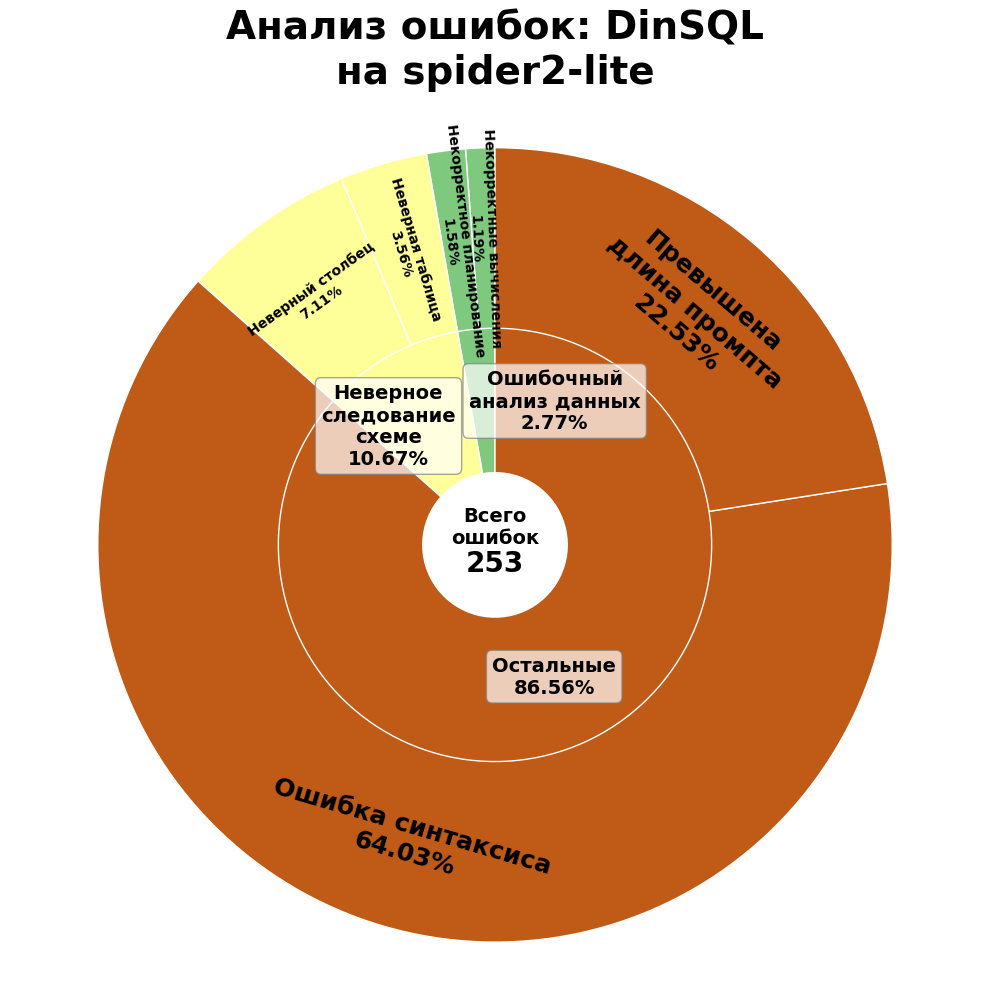

In [27]:
errors_diagram(err_stat, f'Анализ ошибок: DinSQL\nна {dataset}', 1, [(0.2, 0), (-0.1, -0.02), (0, 0)])

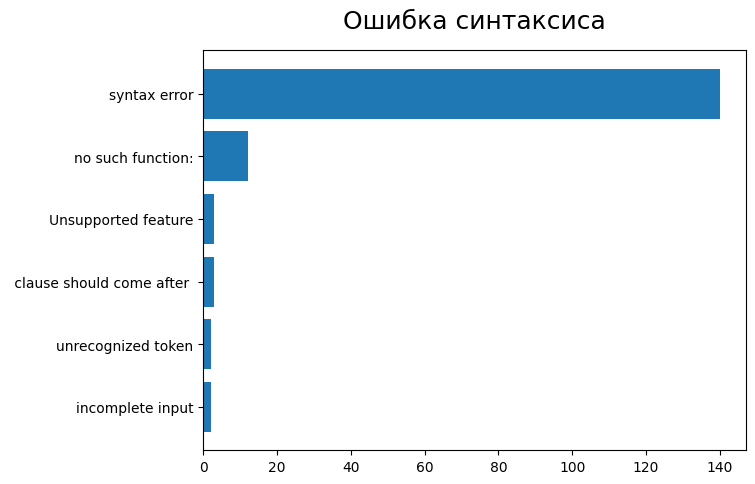

In [20]:
error_subtype_plot(errors, 'Ошибка синтаксиса');

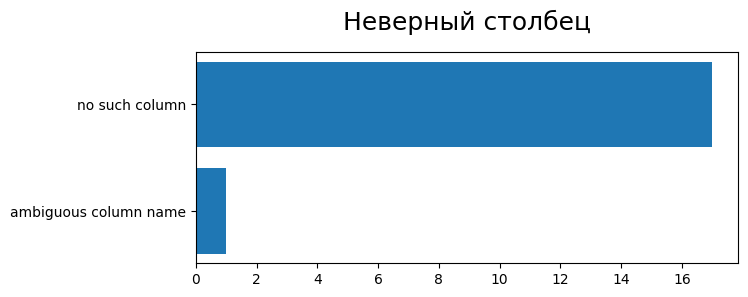

In [21]:
error_subtype_plot(errors, 'Неверный столбец');

## Стоимость

In [133]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_pretrained("upstage/solar-pro-tokenizer")

In [137]:
prompt_tokens = open("..\\benchmarks\Spider2\spider2-lite\\baselines\dinsql\cost.log").readlines()
step_tokens = {}
for line in prompt_tokens:
    tokens, step = line.strip().split(' | ')
    
    if not step_tokens.get(step):
        step_tokens[step] = []
    
    step_tokens[step].append(int(tokens))


In [138]:
print("Входных токенов\n\nЕсли учитывать все промпты\n")
print(*[f"{step}: {sum(tokens):,d}" for step, tokens in step_tokens.items()], sep='\n')
print(f"Total: {sum(sum(tokens) for tokens in step_tokens.values()):,d}")

print("\n\nЕсли учитывать только промпты, подходящие по длине\n")
print(*[f"{step}: {sum(tok for tok in tokens if tok <= 131000):,d}" for step, tokens in step_tokens.items()], sep='\n')
print(f"Total: {sum(sum(tok for tok in tokens if tok <= 131000) for tokens in step_tokens.values()):,d}")

Входных токенов

Если учитывать все промпты

schema: 7,651,207
classification: 19,593,566
medium prompt: 19,909,193
debug: 19,288,155
Total: 66,442,121


Если учитывать только промпты, подходящие по длине

schema: 7,651,207
classification: 3,616,509
medium prompt: 3,917,784
debug: 3,323,984
Total: 18,509,484


In [139]:
import os

sql_folder = "..\\benchmarks\Spider2\spider2-lite\\baselines\dinsql\postprocessed_data\spider2-lite\predicted-SQL"
out_tokens = []
for sql_file in os.listdir(sql_folder):
    out_tokens.append(len(tokenizer.encode(open(os.path.join(sql_folder, sql_file)).read())))

print("Выходных токенов")
print(f"{sum(out_tokens) * 4:,d}")

Выходных токенов
793,428


# DailSQL

## Ошибки

In [42]:
logs = [line.replace('\n', '') for line in open(fr"..\results\logs\{dataset}\{model}_dailsql_logs.txt").readlines()]
logs[:10]

["nohup: appending output to 'nohup.out'",
 '  0% 0/547 [00:00<?, ?it/s]',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3',
 '>>>model: solar-pro3']

In [43]:
gen_logs = []
total_time = 0
for line in logs:
    if not line or line.isspace() or line.startswith(
        ("nohup", "Location:", "Job ID:", "Evaluating SQL:", "WARNING: Key ")
    ) or "GB processed:" in line or "/547 [" in line:
        if line.startswith('100% 547/547'):
            total_time = line.strip().split(' [')[1].split('<', 1)[0]
            total_time = list(map(int, total_time.split(':')))
            total_time = total_time[0] * 60 + total_time[1]

        continue
    
    gen_logs.append(line.strip())

print("Среднее время генерации одного запроса", round(total_time / 547, 3), "сек.")

Среднее время генерации одного запроса 4.837 сек.


In [44]:
gen_logs = gen_logs[:-5]

In [101]:
err_types = {
    'Ошибочный\nанализ данных': {
        "Некорректное\nиспользование функций": [
            "No matching signature for function",
            "ST_GeogPoint failed",
            # "is not defined for arguments of type",
            "DATE_SUB does not support the",
            ("Numeric value", "is not recognized"),
            # "Analytic function cannot be an argument",
            # "Analytic functions cannot be arguments",
        ],
        "Некорректные вычисления": [
            # "which is not allowed in GROUP BY",
            "which is neither grouped nor aggregated",
            # "Queries in UNION ALL have mismatched column count",
            # "division by zero",
            "misuse of window function",
            # "Query error: Analytic function not allowed in Window",
            # "Analytic function cannot be an argument",
            # "Analytic functions cannot be arguments",
            "ggregat",
            "Cumulative window frame unsupported for function",
            ("found", "clause but no window function"),
            # "misuse of aliased window function",
            # "is not supported for window function"
            
        ],
        "Некорректное\nпланирование": [
            "No data found for the specified query",
            "Queries in UNION ALL have mismatched column count",
            # "Correlated subqueries",
            "in UNION ALL has incompatible types",
            # "Queries in UNION ALL have mismatched column count",
            "Values referenced in UNNEST must be arrays",
            ("Actual statement", "did not match the desired statement")
        ]
    }, 
    "Неверное\nследование\nсхеме": {
        "Неверная\nтаблица": [
            "must be qualified with a dataset (e.g. dataset.table)",
            "Invalid project ID",
            "Access Denied: Table",
            "Not found: Dataset",
            "no such table",
            # "Access Denied: Table",
            # "Not found: Table"
        ],
        "Неверный столбец": [
            "ambiguous column name",
            "no such column",
            ("Name", "not found inside"),
            # ("Column name", "is ambiguous at"),
            ("Field name", "does not exist"),
            "invalid identifier",
            ("Object", "does not exist or not authorized"),
            "Object does not exist, or operation cannot be performed",
            ("Schema", "does not exist or not authorized"),
            
            # "circular reference"
        ],
        "Нераспознанное\nимя": [
            "Unrecognized name: "
        ]
    },
    "Остальные": {
        "Ошибка синтаксиса": [
            # "Syntax error: Unexpected identifier",
            "Syntax error: Expected \"",
            "Syntax error: Unexpected end of script",
            "Syntax error: Expected end of input but got",
            "Syntax error: Unexpected keyword",
            # "Syntax error: Expected keyword",
            "Syntax error: Unexpected string literal",
            "Function not found",
            "unrecognized token:",
            "No matching signature for operator",
            # "No matching signature for function",
            "no such function:",
            " clause should come after ",
            "incomplete input",
            # "syntax error",
            # "Bitwise operator",
            "Cannot parse regular expression",
            # "Cannot access field",
            # "Values referenced in",
            # "Invalid cast from",
            # "Bad int64 value",
            # "Field name",
            "Unknown function",
            ("Function", "does not support", "argument type"),
            ("Ordering by expressions of type", "is not allowed at"),
            "Unsupported feature",
            # "You can only execute one statement at a time",
            "Required parameter is missing",
            "Unable to find common supertype for templated argument",
            ("Unable to coerce type", "to expected type"),
            ("requires at least", "arguments"),
            ("accepts at most", "arguments"),
            ("invalid type", "for parameter"),
            ("Can not convert parameter", "of type", "into expected type"),
            "Unsupported data type",
            "Invalid argument types for function",
            # "ORDER BY is out of SELECT",
            # "Invalid timestamp",
            "syntax error"

        ],
        "Превышена длина промпта": ["context_length_exceeded"],
        # "Непонимание\nвнешних знаний": [],
        # "Ошибка\nусловной\nфильтрации": [
        #     # "Subquery of type IN must have only one output column",
        #     # "not allowed in WHERE clause"
        # ],
        # "Неверный JOIN": [
        #     "Correlated subqueries"
        # ]
    }
}
errors = {
    err: {'type': tp, 'subtype': subtp, 'count': 0} 
    for tp in err_types 
    for subtp in err_types[tp] 
    for err in err_types[tp][subtp]
}
skip_errors = [
    # "'NoneType' object is not iterable", 
    "'NoneType' object is not an iterator",
    "SQL compilation error:",
    "Error parsing JSON",
    "Statement reached its statement or warehouse timeout",
    "Shared database is no longer available for use."
]
total_llm_calls = 0

counted_lines = []
for i, line in enumerate(gen_logs):
    if line.startswith(">>>model: "):
        total_llm_calls += 1
        counted_lines.append(i)
        continue

    # if not line.startswith(('[', 'warning', "SQL sli", "Slicing error", "Error occurred")):
    #     print(line)

    for err in errors.keys():
        if isinstance(err, tuple) and all(st in line for st in err):
            errors[err]['count'] += 1
            counted_lines.append(i)
            break

        elif isinstance(err, str) and err in line:
            errors[err]['count'] += 1
            counted_lines.append(i)
            break
    
    if i not in counted_lines and any(err in line for err in skip_errors):
        counted_lines.append(i)

print("В среднем", total_llm_calls / 547, "вызовов LLM")

В среднем 1.0 вызовов LLM


In [102]:
# Проверяем, какие ошибки не учли в статистике
print(*[gen_logs[i] for i in range(len(gen_logs)) if i not in counted_lines], sep='\n')

Argument types: INT64
Signature: DATE(TIMESTAMP, [STRING])
Signature: DATE(DATETIME)
Signature: DATE(INT64, INT64, INT64)
Signature: DATE(DATE)
Signature: DATE(STRING)
Argument types: INT64
Signature: DATE(TIMESTAMP, [STRING])
Signature: DATE(DATETIME)
Signature: DATE(INT64, INT64, INT64)
Signature: DATE(DATE)
Signature: DATE(STRING)
Signature: T1 = T1
Signature: T1 = T1
Input types for <T1>: {INT64, STRING} at [1:765]
Argument types: STRING, GEOGRAPHY, INT64
Signature: ST_DWITHIN(GEOGRAPHY, GEOGRAPHY, FLOAT64, [BOOL])
Argument types: STRING, GEOGRAPHY, INT64
Signature: ST_DWITHIN(GEOGRAPHY, GEOGRAPHY, FLOAT64, [BOOL])
Signature: T1 = T1
Signature: T1 = T1
Input types for <T1>: {INT64, STRING} at [1:441]
Argument types: STRING, STRING, STRING
Signature: DATE(TIMESTAMP, [STRING])
Signature: DATE(DATETIME)
Signature: DATE(INT64, INT64, INT64)
Signature: DATE(DATE)
Signature: DATE(STRING)
Argument types: STRING, STRING, STRING
Signature: DATE(TIMESTAMP, [STRING])
Signature: DATE(DATETIME)

In [103]:
from copy import deepcopy

err_stat = deepcopy(err_types)
for tp in err_stat:
    for subtp in err_stat[tp]:
        err_stat[tp][subtp] = 0

for err in errors.values():
    err_stat[err['type']][err['subtype']] += err['count']

for err_group in list(err_stat.keys()):
    for err_type, c in list(err_stat[err_group].items()):
        if c == 0:
            del err_stat[err_group][err_type]
    
    if not err_stat[err_group]:
        del err_stat[err_group]

err_stat

{'Ошибочный\nанализ данных': {'Некорректное\nиспользование функций': 15,
  'Некорректные вычисления': 9,
  'Некорректное\nпланирование': 24},
 'Неверное\nследование\nсхеме': {'Неверная\nтаблица': 32,
  'Неверный столбец': 155,
  'Нераспознанное\nимя': 28},
 'Остальные': {'Ошибка синтаксиса': 207, 'Превышена длина промпта': 6}}

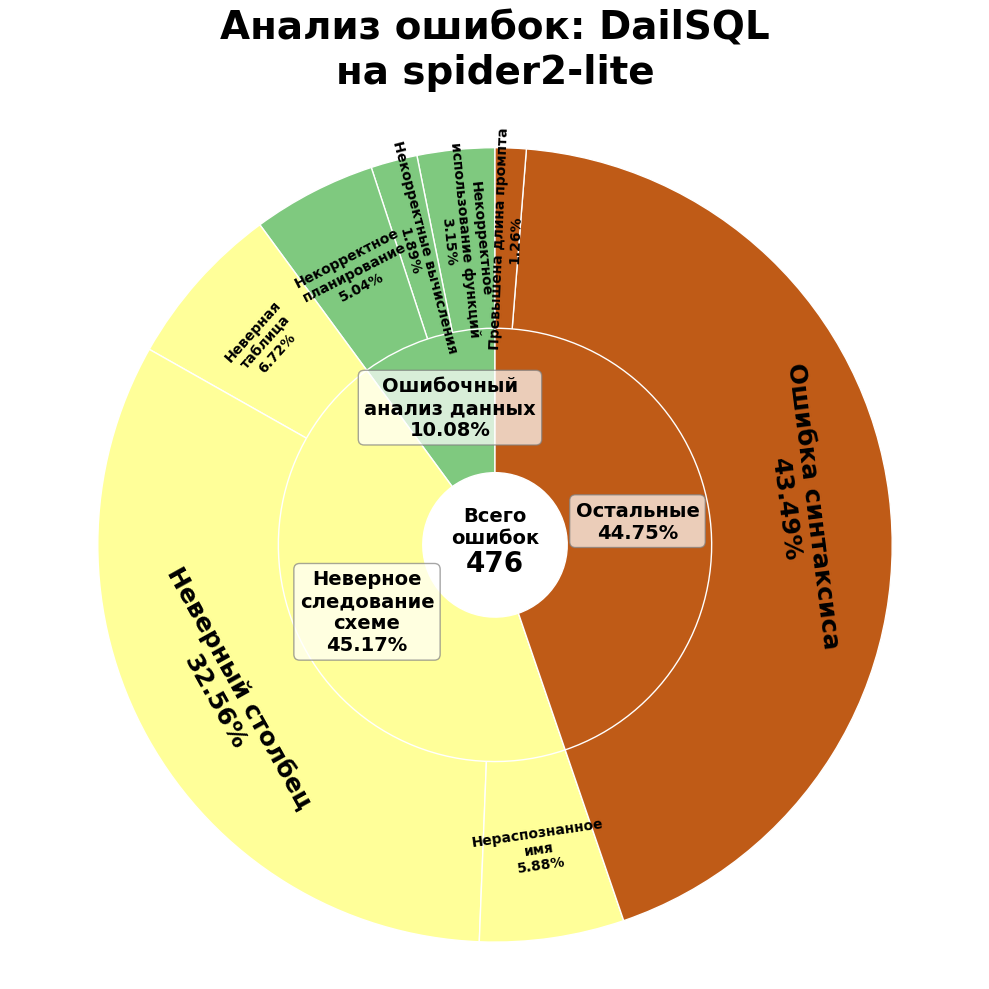

In [104]:
errors_diagram(err_stat, f'Анализ ошибок: DailSQL\nна {dataset}', 3)

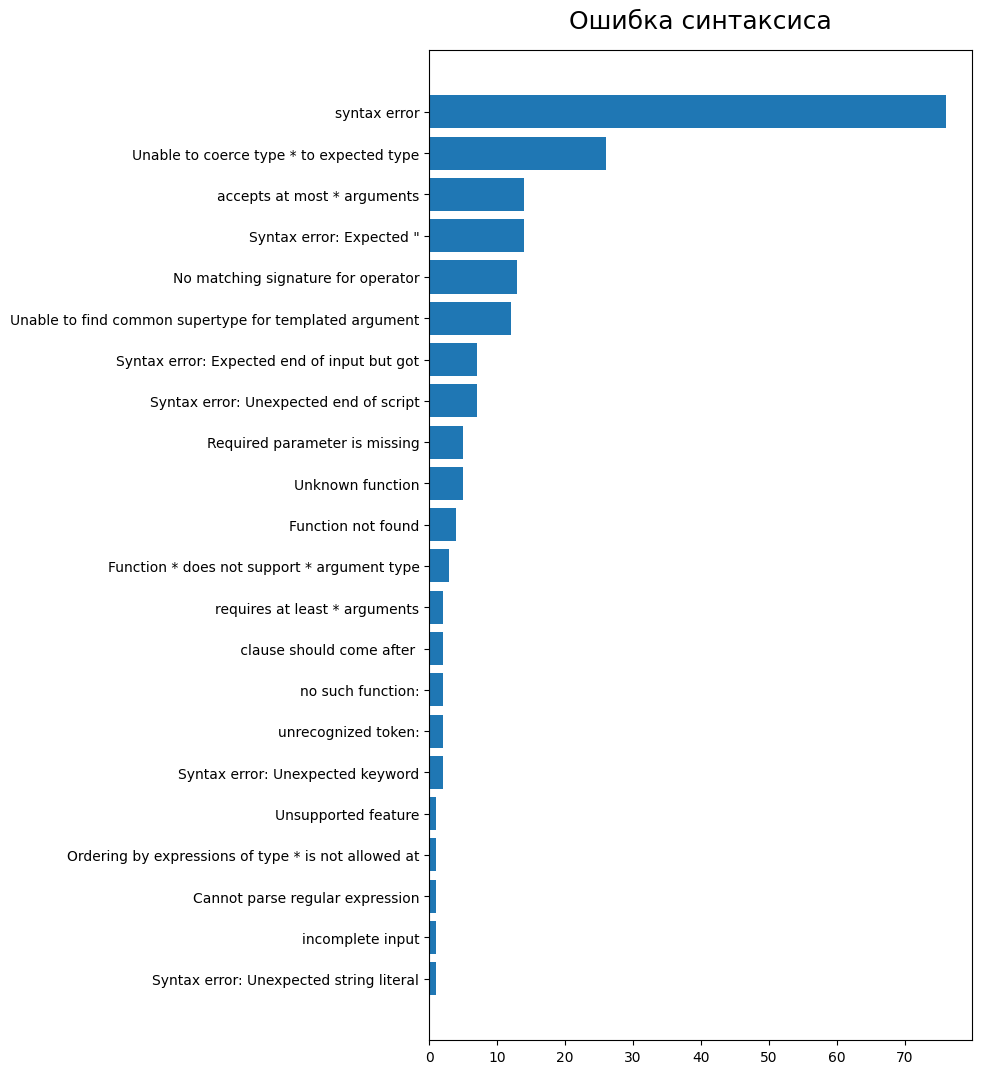

In [69]:
error_subtype_plot(errors, 'Ошибка синтаксиса');

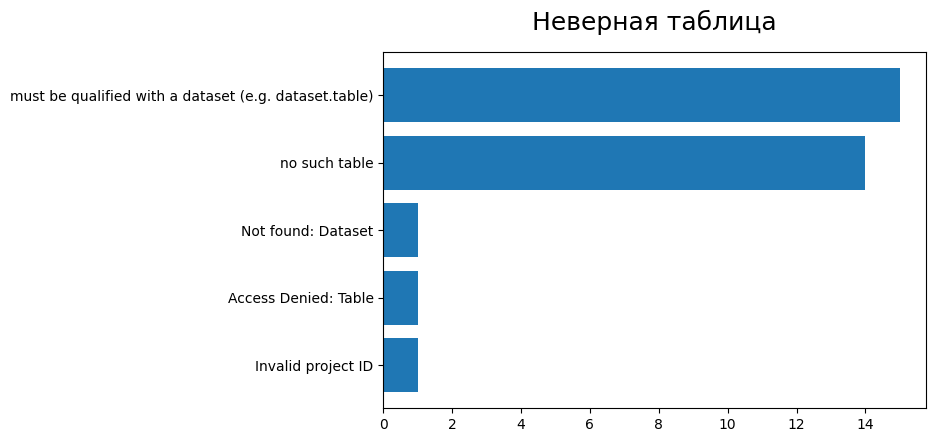

In [ ]:
error_subtype_plot(errors, 'Неверная таблица');

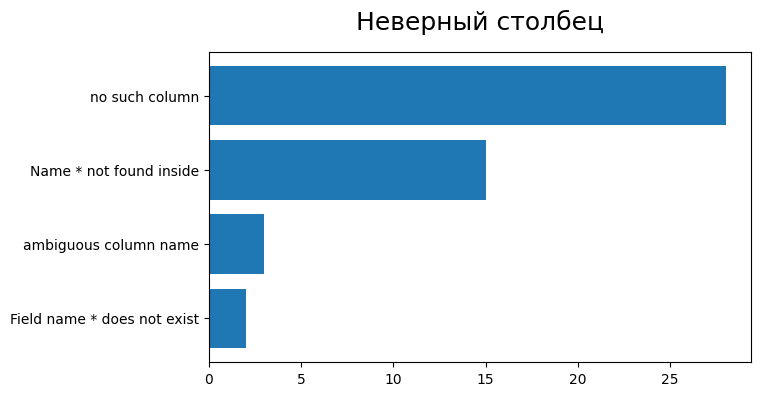

In [ ]:
error_subtype_plot(errors, 'Неверный столбец');

## Стоимость

In [3]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_pretrained("upstage/solar-pro-tokenizer")

e:\Code\ttsql\sqlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import json
import os


cost_folder = "..\\benchmarks\Spider2\spider2-lite\\baselines\dailsql\postprocessed_data\\1112_spider2-lite_CTX-200\RESULTS_MODEL-mistralai\cost"
tokens = []
for cost_file in os.listdir(cost_folder):
    tokens.append(len(tokenizer.encode(json.load(open(os.path.join(cost_folder, cost_file)))['prompt'])))

print("Входных токенов\n")
print(f"{sum(tokens):,d}")

In [7]:
sql_folder = "..\\benchmarks\Spider2\spider2-lite\\baselines\dailsql\postprocessed_data\\1112_spider2-lite_CTX-200\RESULTS_MODEL-mistralai\devstral-2512_free-SQL"
out_tokens = []
for sql_file in os.listdir(sql_folder):
    out_tokens.append(len(tokenizer.encode(open(os.path.join(sql_folder, sql_file)).read())))

print("Выходных токенов")
print(f"{sum(out_tokens):,d}")

Выходных токенов
329,160


# Spider Agent Lite

## Ошибки

In [ ]:
import json
import os


output_folder = r"..\benchmarks\Spider2\methods\spider-agent-lite\output\devstral2-test1"
err_logs = {}
for instance in os.listdir(output_folder):
    if instance.startswith('bq'):
        continue

    if not os.path.exists(os.path.join(output_folder, instance, "spider", 'result.json')):
        continue

    logs = json.load(open(os.path.join(output_folder, instance, "spider", 'result.json'), 'rb'))
    # if instance.startswith('bq') and not logs['result']:
    #     continue

    err_logs[instance] = {"finished": logs["finished"], "steps": logs["steps"], "errors": []}

    for prev_step, step in zip(logs['trajectory'][:-1], logs['trajectory'][1:]):
        if (
            not step['response'] 
            or not prev_step['action']
            or "_SQL(" not in prev_step['action']
        ):
            continue
        
        if step['observation'].startswith("Traceback (most recent call last):"):
            err_logs[instance]['errors'].append(step['observation'])


 * Когда модель не может получить результаты запроса, она либо повторяется, 
 
    либо генерирует искусственный ответ и записывает его в .csv файл

In [ ]:
err_types = {
    'Ошибочный\nанализ данных': {
        "Некорректное\nиспользование\nфункций": [
            "Invalid argument types for function",
            "illegal mixing of named and positional arguments for function",
            "too many arguments for function"
        ],
        "Некорректные\nвычисления": [
            "is neither an aggregate nor in the group by clause",
            "Window function "
        ],
        # "Некорректное\nпланирование": []
    }, 
    "Неверное\nследование\nсхеме": {
        "Неверная\nтаблица": [
            "This session does not have a current database"
        ],
        "Неверный столбец": [
            "ambiguous column name",
            ("invalid identifier ", ".")
        ],
        "Нераспознанное имя": [
            "invalid identifier "
        ]
    },
    "Остальные": {
        "Ошибка синтаксиса": [
            " unexpected '",
            "Unsupported subquery type cannot be evaluated",
            "is not a valid order by expression",
            "Unknown function",
            "is not recognized",
            "invalid type "
        ],
        # "Превышена\nдлина промпта": []
        # "Непонимание\nвнешних знаний": [],
        # "Ошибка\nусловной\nфильтрации": [],
        # "Неверный JOIN": []
    }
}
errors = {
    err: {'type': tp, 'subtype': subtp, 'count': 0} 
    for tp in err_types 
    for subtp in err_types[tp] 
    for err in err_types[tp][subtp]
}

llm_calls = [err_logs[instance]['steps'] for instance in err_logs]

counted_lines = {instance: [] for instance in err_logs}

for instance in err_logs:
    for i, err in enumerate(err_logs[instance]['errors']):
        for err_type, params in errors.items():
            if isinstance(err_type, tuple) and all(st in err.rsplit('\n', 1)[1] for st in err_type):
                errors[err_type]['count'] += 1
                counted_lines[instance].append(i)
                break

            elif isinstance(err_type, str) and err_type in err.rsplit('\n', 1)[1]:
                errors[err_type]['count'] += 1
                counted_lines[instance].append(i)
                break

print("В среднем", sum(llm_calls) / len(err_logs), "вызовов LLM")

В среднем 18.285714285714285 вызовов LLM


In [ ]:
print(*[
    err.rsplit('\n', 1)[1] 
    for instance in err_logs 
    for i, err in enumerate(err_logs[instance]['errors']) 
    if i not in counted_lines[instance]
], sep='\n')

In [ ]:
from copy import deepcopy

err_stat = deepcopy(err_types)
for tp in err_stat:
    for subtp in err_stat[tp]:
        err_stat[tp][subtp] = 0

for err in errors.values():
    err_stat[err['type']][err['subtype']] += err['count']

err_stat

{'Ошибочный\nанализ данных': {'Некорректное\nиспользование\nфункций': 13,
  'Некорректные\nвычисления': 2},
 'Неверное\nследование\nсхеме': {'Неверная\nтаблица': 15,
  'Неверный столбец': 36,
  'Нераспознанное имя': 169},
 'Остальные': {'Ошибка синтаксиса': 49}}

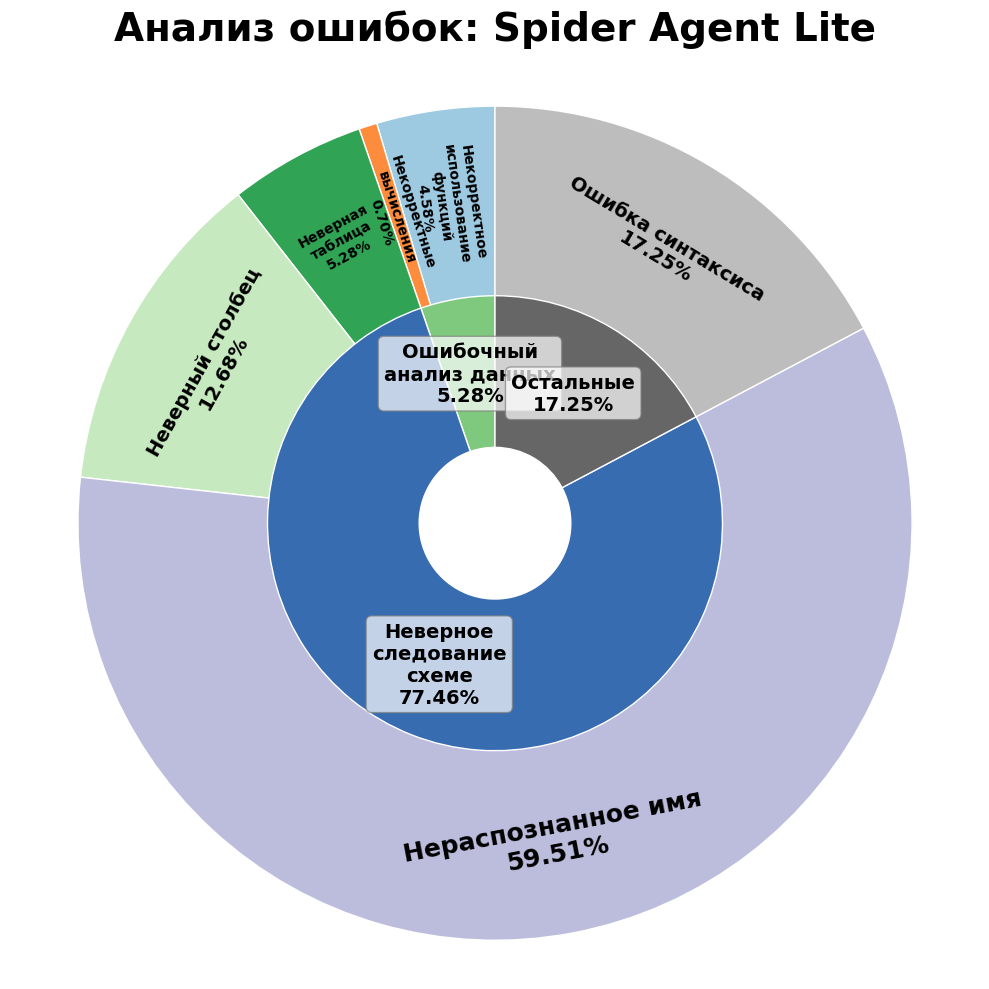

In [ ]:
errors_diagram(err_stat, 'Анализ ошибок: Spider Agent Lite', 1)

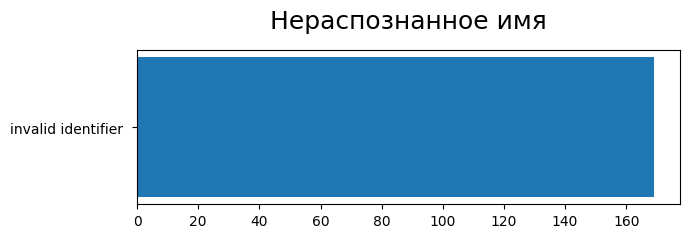

In [ ]:
error_subtype_plot(errors, "Нераспознанное имя");

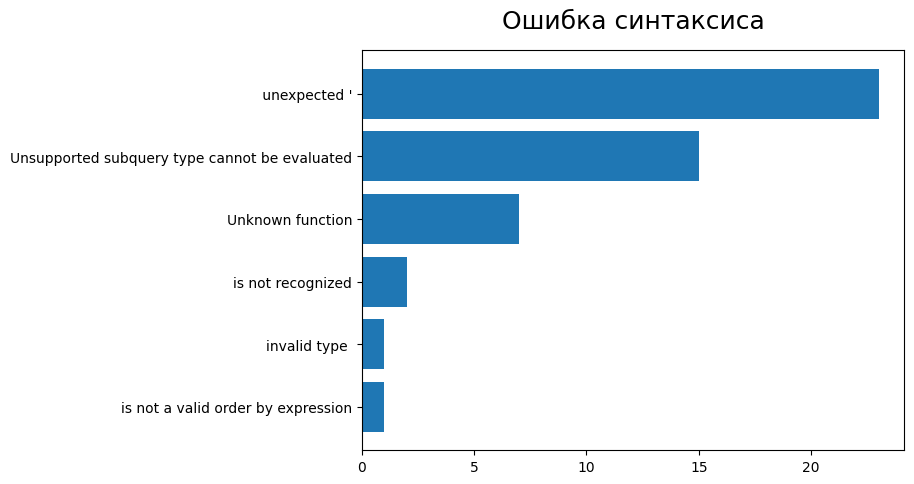

In [ ]:
error_subtype_plot(errors, 'Ошибка синтаксиса');

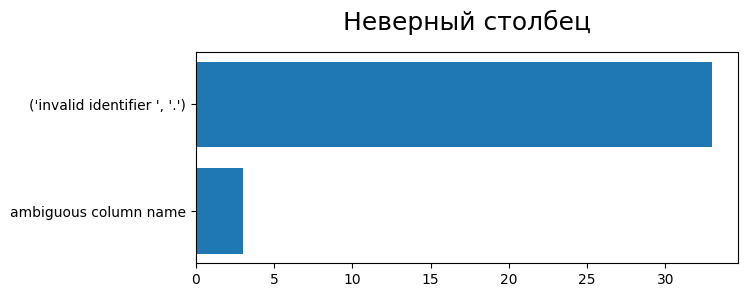

In [ ]:
error_subtype_plot(errors, "Неверный столбец");

## Время выполнения

In [ ]:
from datetime import datetime

time_logs = {}
logs_folder = r"..\benchmarks\Spider2\methods\spider-agent-lite\logs"
for log_file in os.listdir(logs_folder)[4:]:
    logs = open(os.path.join(logs_folder, log_file), 'r', encoding='utf-8').readlines()
    instance = ""
    for line in logs:
        try:
            dt, tm, message = line.strip()[8:].split(' ', 2)
            message = message.split('] ', 1)[1][4:].split('(', 1)[0]
            
            if message.startswith(('Running ', "Step ", "Finished ", "Failed to parse action")):
                if message.startswith('Running '):
                    if instance:
                        time_logs[instance].sort(key=lambda x: x[0])

                    instance = message.split(' ', 1)[1].rsplit("/", 1)[1]
                    time_logs[instance] = [(datetime.fromisoformat(dt + ' ' + tm), message)]
                elif (message.startswith("Failed to parse action") 
                    and int(time_logs[instance][-1][1].split(': ')[0].split(' ')[1]) != 20):  # number of previous step
                    time_logs[instance].append((
                        datetime.fromisoformat(dt + ' ' + tm), 
                        f"Step {int(time_logs[instance][-1][1].split(': ')[0].split(' ')[1]) + 1}: " + message
                    ))
                elif not message.startswith("Failed to parse action"):
                    time_logs[instance].append((datetime.fromisoformat(dt + ' ' + tm), message))

                # print(time_logs[instance][-1][0])
                # print(time_logs[instance][-1][1])

        except (IndexError, ValueError):
            continue
    
    time_logs[instance].sort(key=lambda x: x[0])


In [ ]:
total_time = {}
steps_time = {}
for instance in time_logs:
    start, end = None, None
    steps_time[instance] = {}
    for step in time_logs[instance]:
        if step[1].startswith('Running '):
            start = step[0]
        elif step[1].startswith('Finished '):
            end = step[0]
        # elif step[1].startswith('Failed to parse action'):
        else:
            action = step[1].split(": ", 1)[0]

            if not steps_time[instance].get(action):
                steps_time[instance][action] = (step[0], None)
            else:
                steps_time[instance][action] = (steps_time[instance][action][1] - step[0]).total_seconds()
            
            if int(action.split(' ')[1]) == 1:
                continue

            prev_action = "Step " + str(int(action.split(' ')[1]) - 1)
            if not steps_time[instance].get(prev_action):
                steps_time[instance][prev_action] = (None, step[0])
            else:
                steps_time[instance][prev_action] = (step[0] - steps_time[instance][prev_action][0]).total_seconds()
        
    if start is not None and end is not None:
        total_time[instance] = (end - start).total_seconds()
    
        missed_steps = sorted([
                step for step in steps_time[instance] 
                if isinstance(steps_time[instance][step], tuple)
            ], 
            key=lambda x: int(x.split(' ')[1])
        )
        if not missed_steps:
            continue

        for step in missed_steps[:-1]:
            del steps_time[instance][step]
        
        steps_time[instance][missed_steps[-1]] = (end - steps_time[instance][missed_steps[-1]][0]).total_seconds()
    else:
        steps_time[instance] = {step: steps_time[instance][step]
                                for step in steps_time[instance] 
                                if not isinstance(steps_time[instance][step], tuple)}


In [ ]:
from datetime import timedelta

print("Потрачено времени\n")
print("Всего\t\t\t", timedelta(seconds=sum(total_time.values())), sep='\t')
print("В среднем на один пример", timedelta(seconds=sum(total_time.values()) / len(total_time)), sep='\t', end='\n\n')

q = list(total_time.values())
q.sort()
print("50% квантиль\t\t", timedelta(seconds=q[int(len(q) * 0.5 + 1)]), sep='\t')
print("90% квантиль\t\t", timedelta(seconds=q[int(len(q) * 0.9 + 1)]), sep='\t')
print("95% квантиль\t\t", timedelta(seconds=q[int(len(q) * 0.95 + 1)]), sep='\t')

Потрачено времени

Всего				8:46:05.090000
В среднем на один пример	0:02:55.361611

50% квантиль			0:02:49.281000
90% квантиль			0:04:35.240000
95% квантиль			0:05:14.746000


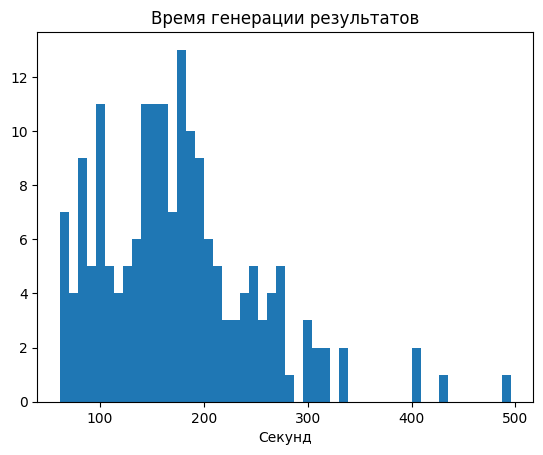

In [ ]:
import matplotlib.pyplot as plt


plt.hist(list(total_time.values()), bins=50)
plt.xlabel("Секунд")
plt.title("Время генерации результатов");

In [ ]:
steps_time_stat = {}
for instance in steps_time:
    for step in steps_time[instance]:
        if not steps_time_stat.get(step):
            steps_time_stat[step] = []

        steps_time_stat[step].append(steps_time[instance][step])

# print(*[f"{step}\t\t{sum(data) / len(data):.3f}\tсек." for step, data in steps_time_stat.items()], sep='\n')

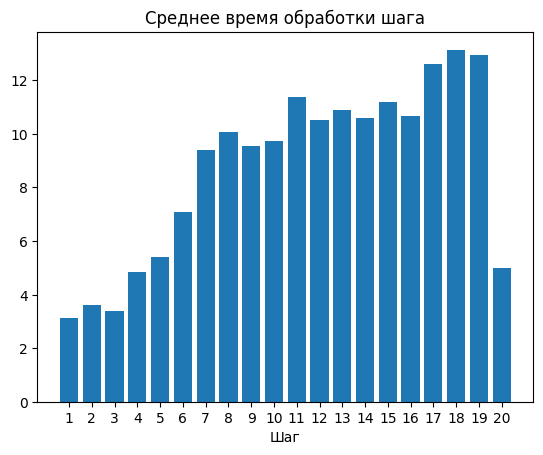

In [ ]:
plt.bar(list(map(lambda x: x.split(' ')[1], steps_time_stat.keys())), 
        list(map(lambda x: sum(x) / len(x), steps_time_stat.values())))
plt.xlabel("Шаг")
plt.title("Среднее время обработки шага");

## Стоимость

In [ ]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_pretrained("upstage/solar-pro-tokenizer")

e:\Code\ttsql\sqlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
import json
import os


output_folder = r"..\benchmarks\Spider2\methods\spider-agent-lite\output\devstral2-test1"
instance_tokens = {}
responce_tokens = {}
memory_len = 10
for instance in os.listdir(output_folder):
    if instance.startswith('bq'):
        continue

    if not os.path.exists(os.path.join(output_folder, instance, "spider", 'result.json')):
        continue

    logs = json.load(open(os.path.join(output_folder, instance, "spider", 'result.json'), 'rb'))
    messages = [len(tokenizer.encode(logs['system_message']))]
    instance_tokens[instance] = 0
    responce_tokens[instance] = 0
    for step in logs["trajectory"]:
        if step["observation"]:
            messages.append(len(tokenizer.encode(step["observation"])))
        
        if step["thought"]:
            messages.append(len(tokenizer.encode(step["thought"])))

        if len(messages) > 2*memory_len + 1:
            messages = [messages[0]] + messages[-2*memory_len:]

        instance_tokens[instance] += sum(messages)

        if step["response"]:
            responce_tokens[instance] += len(tokenizer.encode(step["response"]))


In [ ]:
print("Входных токенов\n")
print(f"Всего токенов за {len(instance_tokens)} примеров")
print(f"{sum(instance_tokens.values()):,d}\n")

print("В среднем на пример")
mean_in_tokens = sum(instance_tokens.values()) / len(instance_tokens)
print(f"{int(mean_in_tokens):,d}\n")

q = list(instance_tokens.values())
q.sort()
print(f"50% квантиль\t{q[int(len(q)*0.5 + 1)]:,d}")
print(f"90% квантиль\t{q[int(len(q)*0.9 + 1)]:,d}")
print(f"95% квантиль\t{q[int(len(q)*0.95 + 1)]:,d}")


Входных токенов

Всего токенов за 112 примеров
18,391,017

В среднем на пример
164,205

50% квантиль	143,429
90% квантиль	301,178
95% квантиль	419,426


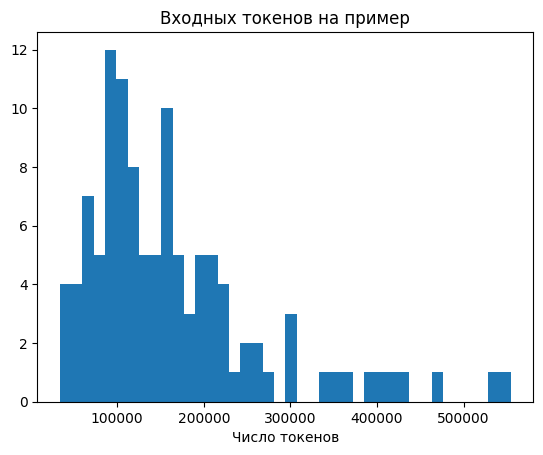

In [ ]:
import matplotlib.pyplot as plt


plt.hist(list(instance_tokens.values()), bins=40)
plt.xlabel("Число токенов")
plt.title("Входных токенов на пример");

In [ ]:
# Берём для оценки среднее число токенов на пример
# и смотрим какой это квантиль

eval_in_tokens = mean_in_tokens
print(f"В качестве оценки взят {sum(t <= eval_in_tokens for t in q) / len(q):.2f} квантиль\nраспределения входных токенов на пример\n")
print("Приблизительно всего входных токенов")
print(f"{int(eval_in_tokens * 547) + 1:,d}")

В качестве оценки взят 0.63 квантиль
распределения входных токенов на пример

Приблизительно всего входных токенов
89,820,414


In [ ]:
print("Выходных токенов\n")
print(f"Всего токенов за {len(responce_tokens)} примеров")
print(f"{sum(responce_tokens.values()):,d}\n")

print("В среднем на пример")
mean_in_tokens = sum(responce_tokens.values()) / len(responce_tokens)
print(f"{int(mean_in_tokens):,d}\n")

q = list(responce_tokens.values())
q.sort()
print(f"50% квантиль\t{q[int(len(q)*0.5 + 1)]:,d}")
print(f"90% квантиль\t{q[int(len(q)*0.9 + 1)]:,d}")
print(f"95% квантиль\t{q[int(len(q)*0.95 + 1)]:,d}")

Выходных токенов

Всего токенов за 112 примеров
259,496

В среднем на пример
2,316

50% квантиль	2,070
90% квантиль	3,355
95% квантиль	4,109


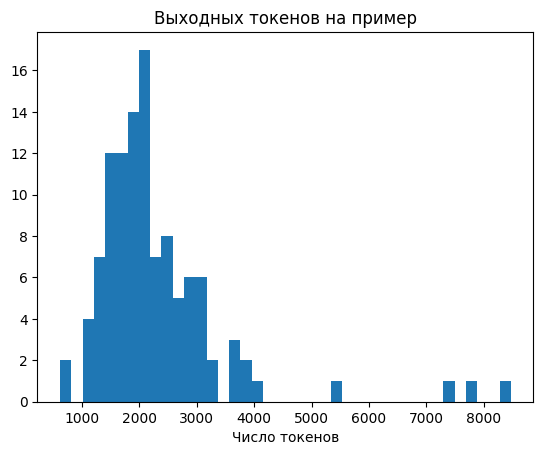

In [ ]:
plt.hist(list(responce_tokens.values()), bins=40)
plt.xlabel("Число токенов")
plt.title("Выходных токенов на пример");

In [ ]:
# Берём для оценки среднее число токенов на пример
# и смотрим какой это квантиль

eval_in_tokens = mean_in_tokens
print(f"В качестве оценки взят {sum(t <= eval_in_tokens for t in q) / len(q):.2f} квантиль\nраспределения выходных токенов на пример\n")
print("Приблизительно всего выходных токенов")
print(f"{int(eval_in_tokens * 547) + 1:,d}")

В качестве оценки взят 0.67 квантиль
распределения выходных токенов на пример

Приблизительно всего выходных токенов
1,267,360


# ReFoRCE

## Ошибки

In [ ]:
import json
import os
import re
import datetime
from multiprocessing.pool import ThreadPool


def process_instance(folder, inst, cand):
    global logs, log_pattern

    num_idx = 1
    
    while cand[:num_idx + 1].isdigit() and num_idx <= len(cand):
        num_idx += 1
    
    # print(datetime.datetime.now(), cand)
    try:
        lognum = int(cand[:num_idx])
    except ValueError:
        lognum = 0

    with open(os.path.join(folder, inst, cand), 'r', encoding='utf-8') as f:
        step = ""
        ts = ""
        for line in f.readlines():
            if not logs[inst].get(lognum):
                logs[inst][lognum] = []

            line = line.strip()
            if line.startswith("[") and line.endswith("]"):
                continue

            if re.match(log_pattern, line):
                ts, *_, step = line.split(" - ", 3)
                logs[inst][lognum].append(((ts, step, "")))
                continue
            
            if step == "[Error occurred]":
                try:
                    logs[inst][lognum][-1] = (ts, step, dict(line))
                except (TypeError, ValueError):
                    logs[inst][lognum][-1] = (ts, step, line)
                
                continue

            if line == "user:":
                step = step + " input"
                continue
            elif line == "assistant:":
                step = step.rsplit(" ", 1)[0] + " output"
                logs[inst][lognum].append((ts, step, ""))
                continue
            
            # print(logs[inst][lognum], line)
            logs[inst][lognum][-1] = (ts, step, logs[inst][lognum][-1][2] + "\n" + line)

            # print(step)
    

log_pattern = re.compile(
    r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2} - .* - .* - .*'
)
folder = f"..\\benchmarks\Spider2\methods\ReFoRCE\output\solar-pro3-{dataset.rsplit('-', 1)[1]}-log"
logs = {}
for inst in os.listdir(folder):
    logs[inst] = {}
    with ThreadPool(3) as pool:
        pool.starmap(
            process_instance, 
            [(folder, inst, cand) for cand in os.listdir(os.path.join(folder, inst)) 
             if cand.endswith(".log") and cand != "log.log"]
        )
    
    # for cand in os.listdir(os.path.join(folder, inst)):
    #     if cand.endswith(".log") and cand != "log.log":
    #         process_instance(folder, inst, cand)


# folder = f"..\\benchmarks\Spider2\methods\ReFoRCE\examples_{dataset.rsplit('-', 1)[1]}"
# logs = dict.fromkeys(os.listdir(folder), {})
# with ThreadPool(3) as pool:
#     pool.starmap(
#         process_instance, 
#         [(folder, inst, "log.log") for inst in os.listdir(folder) 
#          if os.path.exists(os.path.join(folder, inst, "log.log"))]
#     )

json.dump(logs, open(f"..\\results\\logs\\{dataset}\\reforce_logs2.json", 'w', encoding='utf-8'), ensure_ascii=False, indent=2)

In [ ]:
import json

logs1 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs1.json", 'r', encoding='utf-8'))
logs2 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs2.json", 'r', encoding='utf-8'))

MemoryError: 

In [ ]:
gen_logs1, gen_logs2, pre_logs = [], []
for logs, gen_logs in ((logs1, gen_logs1), (logs2, gen_logs2), ()):
    for inst in logs:
        for cand in logs[inst]:
            if len(logs[inst][cand]) == 1:
                gen_logs.append("Context length exceeded")

            for line in logs[inst][cand]:
                error = None
                if line[1] == "[Error occurred]" and line[2]:
                    error = eval(line[2].strip())['error_msg']
                    if error.startswith('{'):
                        try:
                            error = eval(error)['error_msg']
                        except (ValueError, TypeError):
                            pass

                    error = error.replace("\\n", "\n")

                elif line[1].startswith("[Results for corrected sql]") and line[2].strip().startswith("{'"):
                    try:
                        error = eval(line[2].strip())['error_msg']
                    except (ValueError, TypeError):
                        continue
                    
                    if error.startswith('{'):
                        try:
                            error = eval(error)['error_msg']
                        except (ValueError, TypeError):
                            pass

                    error = error.replace("\\n", "\n")
                    
                elif "No data found" in line[1]:
                    error = line[1]
                elif "No data found" in line[2]:
                    error = line[2]
                elif isinstance(line[2], str) and line[2].strip().startswith("The error information is"):
                    error = eval(line[2].strip().split('\n')[1].strip())['error_msg']
                    if error.startswith('{'):
                        try:
                            error = eval(error)['error_msg']
                        except (ValueError, TypeError):
                            pass

                    error = error.replace("\\n", "\n")
                
                if error is not None:
                    # if '{' in error:
                    #     print('------\n', error, '\n------')

                    gen_logs.append(error)
                

In [132]:
err_types = {
    'Ошибочный\nанализ данных': {
        "Некорректное\nиспользование функций": [
            "No matching signature for function",
            "ST_GeogPoint failed",
            "DATE_SUB does not support the",
            ("Numeric value", "is not recognized"),
            ("Type", "is not supported as argument to"),
            "Unknown parameter",
            "near \"QUALIFY\"",
            "unexpected 'QUALIFY'",
            "unexpected 'LATERAL'",
            "is not defined for arguments of type",
            ("Column", "of type", "cannot be used in")
        ],
        "Некорректные вычисления": [
            "which is neither grouped nor aggregated", "misuse of window function",
            "wrong number of arguments to function", "Division by zero", "misuse of aggregate",
            "is not supported for window functions", "recursive aggregate queries not supported",
            "misuse of aliased window function", "Invalid floating point operation",
            "unexpected 'AVG'", "unexpected 'test_score'", "unexpected 'ARRAY_AGG'",
            "No matching signature for aggregate function", ("Aggregate function", "not allowed in"),
            ("Grouping by expressions of type", "is not allowed"),
            ("Aggregate functions with", "cannot be used with arguments of type"),
            "Aggregations of aggregations are not allowed", "Cannot GROUP BY literal values",
            ("Expressions of type", "cannot be used as GROUP BY keys"),

        ],
        "Некорректное\nпланирование": [
            "No data found for the specified query",
            "Queries in UNION ALL have mismatched column count",
            "in UNION ALL has incompatible types",
            "Values referenced in UNNEST must be arrays",
            ("Actual statement", "did not match the desired statement"),
            "Single-row subquery returns more than one row",
            "near \"GROUP\"", "unexpected 'UNION'",
            ("Subquery of type", "must have only one output column"),
            "near \"UNION\""
        ]
    }, 
    "Неверное\nследование\nсхеме": {
        "Неверная\nтаблица": [
            "must be qualified with a dataset (e.g. dataset.table)",
            "Invalid project ID",
            "Access Denied: Table",
            "Not found: Dataset",
            "no such table",
            "This session does not have a current database",
            ("Table", "was not found"),
            "Cannot read partition information from a table that is not partitioned"
        ],
        "Неверный\nстолбец": [
            "ambiguous column name",
            "no such column",
            ("Name", "not found inside"),
            ("Name", "is ambiguous inside"),
            ("Column name", "is ambiguous at"),
            ("Field name", "does not exist"),
            "circular reference",
            "Cannot access field",
            "Wildcard matched incompatible partitioning/clustering tables"
        ],
        "Нераспознанное\nимя": [
            "Unrecognized name: ",
        ]
    },
    "Остальные": {
        "Превышена\nдлина промпта": ["Context length exceeded"],
        # "Непонимание\nвнешних знаний": [],
        "Ошибка\nусловной фильтрации": [
            # "Subquery of type IN must have only one output column",
            # "not allowed in WHERE clause"
            "near \"WHERE\"",
            "unexpected 'FILTER'",
            "unexpected 'WHERE'",
            "Analytic function not allowed in WHERE clause"
        ],
        "Неверный JOIN": [
            "Correlated subqueries",
            "near \"CROSS\"",
            "nexpected 'CROSS'",
            "unexpected 'LEFT'",
            "unexpected 'JOIN'",
            "Unsupported subquery with table in join predicate.",
            "IN subquery is not supported inside join predicate",
            ("Column", "in", "clause not found on left side of join"),
            "JOIN cannot be used without a condition",
            "a JOIN clause is required before ON",
        ],
        "Ошибка синтаксиса": [
            "Syntax error: Unexpected identifier", "Syntax error: Expected \"", "Syntax error: Unexpected end of script",
            "Syntax error: Expected end of input but got", "Syntax error: Unexpected keyword", "Syntax error: Expected keyword",
            "Syntax error: Unexpected string literal", "Function not found", "unrecognized token:", 
            "Unclosed identifier literal", "Occurrence must be positive",
            "No matching signature for operator", "No matching signature for function", "no such function:",
            " clause should come after ", "incomplete input", "Cannot parse regular expression", "Invalid regular expression",
            "ordinal must be", "date value out of range", ("Timestamp", "is not recognized"),
            ("Can't parse", "as timestamp with format"), ("Can't parse", "as date with format"),
            ("Date", "is not recognized"), ("Bad output format", "for FIXED"), ("Failed to cast variant value", "to"),
            ("Ordering by expressions of type", "is not allowed at"), ("value", "is not recognized"),
            ("Can't parse", "as number with format"), "Unknown timezone", "Invalid Lng/Lat pair", "Error parsing WKT input",
            "is out of range", "out of representable range", "Unsupported feature", "You can only execute one statement at a time.",
            "Required parameter is missing", "malformed JSON", "Left argument of string is not an array", "Invalid extraction path",
            "concatenated string literals must be separated by whitespace or comments", "Bad int64 value",
            "ORDER BY key must be numeric in a RANGE-based window", ("does not support the", "date part when the argument is", "type"),
            "A valid date part name is required but found", "in arguments is not supported on scalar functions",
            "Illegal escape sequence", "produced too many elements", "ORDER BY term does not match any column in the result set",
            "Bad input format model", ("String", "is too long and would be truncated"), "unexpected", 

            "syntax error"
        ]
    }
}
errors = {
    err: {'type': tp, 'subtype': subtp, 'count': 0} 
    for tp in err_types 
    for subtp in err_types[tp] 
    for err in err_types[tp][subtp]
}
skip_errors = [
    "'NoneType' object is not iterable", 
    "'NoneType' object is not an iterator",
    "SQL compilation error:",
    "Error parsing JSON",
    "Statement reached its statement or warehouse timeout",
    "Timed out",
    "returned NULL without setting an exception",
    "Insufficient privileges to operate on schema",
    "Python int too large",
    "SQL execution internal error",
    "database or disk is full",
    "Quota exceeded",
    "Connection broken"
]

counted_lines = []
for i, line in enumerate(gen_logs2):
    for err in errors.keys():
        if isinstance(err, tuple) and all(st in line for st in err):
            errors[err]['count'] += 1
            counted_lines.append(i)
            break

        elif isinstance(err, str) and err in line:
            errors[err]['count'] += 1
            counted_lines.append(i)
            # if err == 'syntax error':
            #     print(line)
            break
    
    if i not in counted_lines and any(err in line for err in skip_errors):
        counted_lines.append(i)


In [125]:
# Проверяем, какие ошибки не учли в статистике
print(*[gen_logs2[i] for i in range(len(gen_logs2)) if i not in counted_lines], sep='\n')


```sql
--Description: The original query listed MIDs of movies with no cast via a LEFT JOIN and NULL check, which returns an empty set when no such movies exist. To guarantee a result (a single row with a count), we simplify by using NOT EXISTS with COUNT(*). This returns 0 when there are no movies without cast, avoiding the "No data found" situation.
SELECT COUNT(*) AS movies_without_cast
FROM "Movie" M
WHERE NOT EXISTS (SELECT 1 FROM "M_Cast" C WHERE C."MID" = M."MID");
```

--Description: Check if any matches have NULL in goal columns (using COUNT instead of SELECT rows to avoid "No data found" when none exist)
SELECT COUNT(*) AS "missing_goal_count" FROM "Match" WHERE "home_team_goal" IS NULL OR "away_team_goal" IS NULL;

Successfully executed. SQL:
--Description: Check if any matches have NULL in goal columns (using COUNT instead of SELECT rows to avoid "No data found" when none exist)
SELECT COUNT(*) AS "missing_goal_count" FROM "Match" WHERE "home_team_goal" IS NULL OR "away_te

In [133]:
from copy import deepcopy

err_stat = deepcopy(err_types)
for tp in err_stat:
    for subtp in err_stat[tp]:
        err_stat[tp][subtp] = 0

for err in errors.values():
    err_stat[err['type']][err['subtype']] += err['count']

for err_group in list(err_stat.keys()):
    for err_type, c in list(err_stat[err_group].items()):
        if c == 0:
            del err_stat[err_group][err_type]
    
    if not err_stat[err_group]:
        del err_stat[err_group]

err_stat

{'Ошибочный\nанализ данных': {'Некорректное\nиспользование функций': 47,
  'Некорректные вычисления': 46,
  'Некорректное\nпланирование': 1177},
 'Неверное\nследование\nсхеме': {'Неверная\nтаблица': 152,
  'Неверный\nстолбец': 140,
  'Нераспознанное\nимя': 95},
 'Остальные': {'Превышена\nдлина промпта': 300,
  'Ошибка\nусловной фильтрации': 11,
  'Неверный JOIN': 14,
  'Ошибка синтаксиса': 628}}

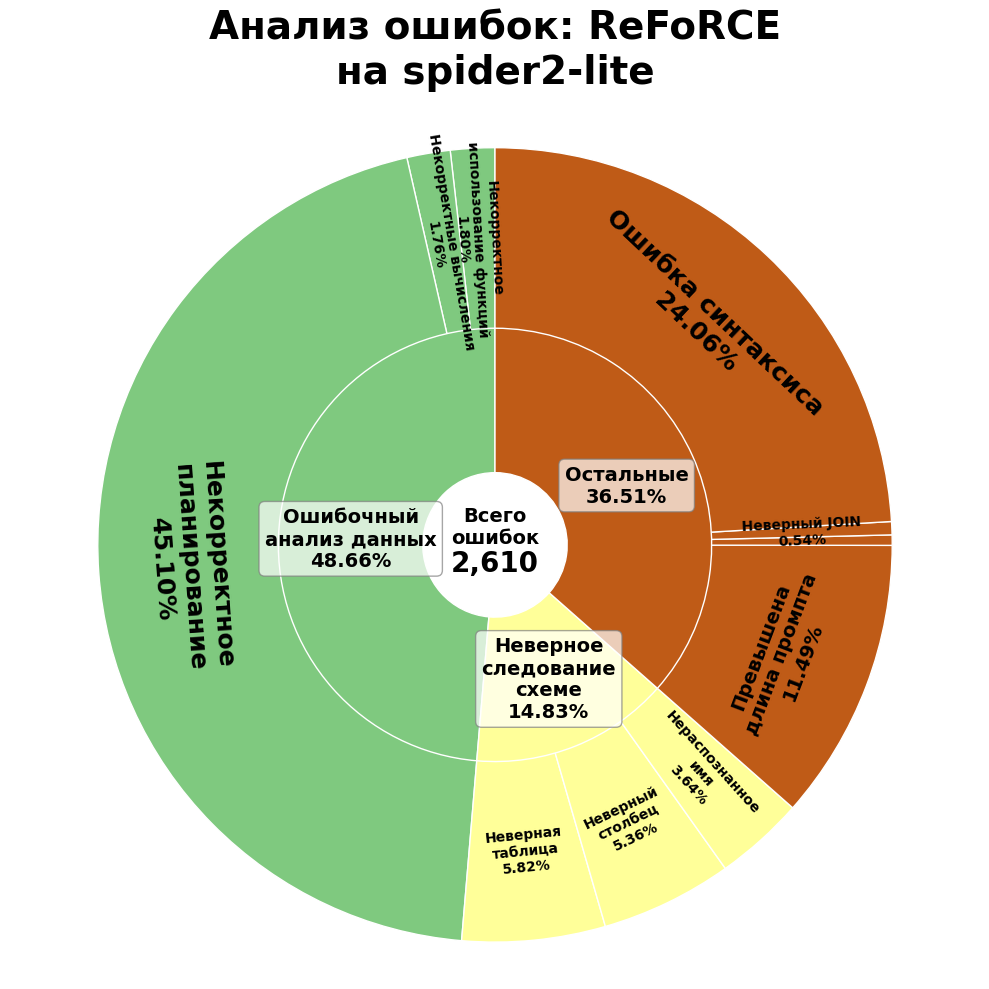

In [134]:
errors_diagram(err_stat, f'Анализ ошибок: ReFoRCE\nна {dataset}', 11, ((0.0, 0), (0.0, 0.0), (0, 0)))

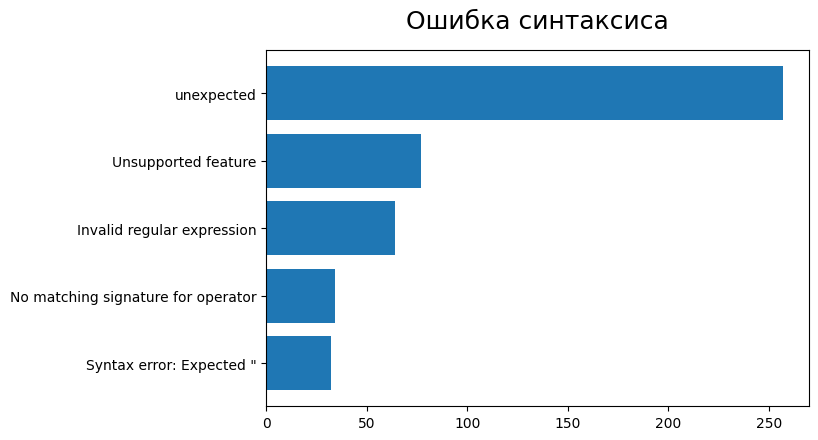

In [135]:
error_subtype_plot(errors, 'Ошибка синтаксиса', 5);

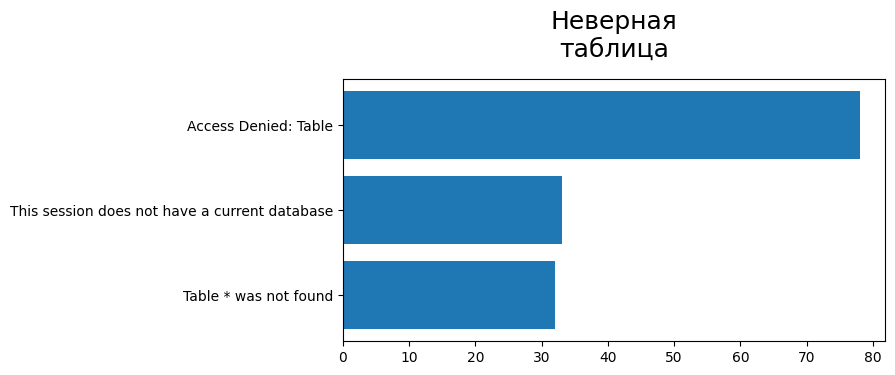

In [137]:
error_subtype_plot(errors, 'Неверная\nтаблица', 3);

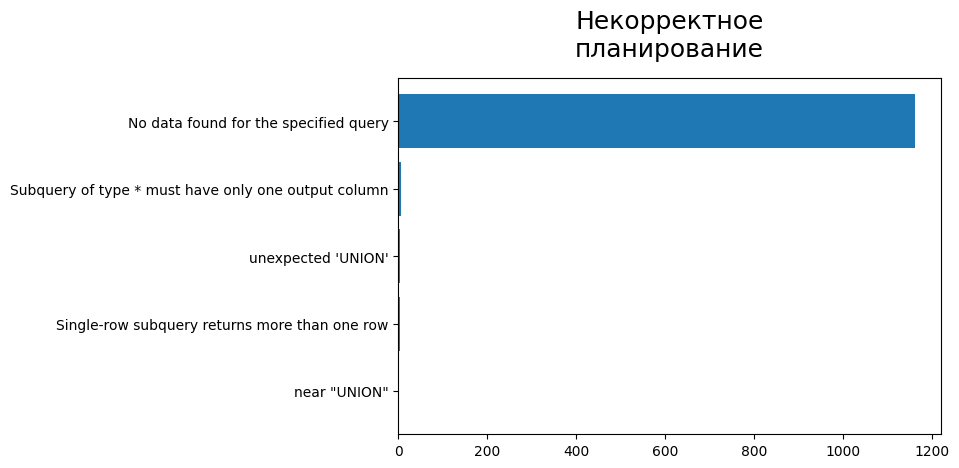

In [138]:
error_subtype_plot(errors, 'Некорректное\nпланирование', 5);

## Время выполнения

### Время на предобработку

In [5]:
import os
import re
from datetime import datetime

log_pattern = re.compile(
    r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2} - .* - .* - .*'
)
prepr_time = {}
prepr_folder = rf"..\benchmarks\Spider2\methods\ReFoRCE\examples_{dataset.split('-')[1]}"
for inst in os.listdir(prepr_folder):
    try:
        with open(os.path.join(prepr_folder, inst, "prompts.txt"), 'r', encoding='utf-8') as f:
            prompt = f.read().strip()
            prepr_time[inst] = {'total_tables': prompt.count("Table full name: "), 'timestamps': [], 'calls': []}

        with open(os.path.join(prepr_folder, inst, 'log.log'), 'r', encoding='utf-8') as f:
            prepr_logs = f.read().strip()
    except FileNotFoundError:
        if prepr_time.get(inst) is not None:
            del prepr_time[inst]

        continue
    
    if not prepr_logs or len(prepr_logs.splitlines()) < 3:
        continue
    
    for line in prepr_logs.splitlines():
        if re.match(log_pattern, line):
            timestamp = line.split(' - ', 1)[0]
            timestamp = datetime.fromisoformat(timestamp)    
            prepr_time[inst]['timestamps'].append(timestamp)
            if len(prepr_time[inst]['timestamps']) > 1:
                prepr_time[inst]['calls'].append((prepr_time[inst]['timestamps'][-1] - prepr_time[inst]['timestamps'][-2]).seconds)
    
    prepr_time[inst]['calls'] = list(filter(lambda x: x > 0, prepr_time[inst]['calls']))


In [6]:
group_pre_time = {group: [] for group in ['bq', 'ga', 'local', 'sf_bq', 'sf0']}
for inst in prepr_time:
    call_times = prepr_time[inst]['calls']
    if not call_times:
        continue

    for group in group_pre_time:
        if inst.startswith(group):
            group_pre_time[group].append(call_times)
            break

print({group: sum(len(group_pre_time[group][i]) for i in range(len(group_pre_time[group]))) for group in group_pre_time})

{'bq': 1864, 'ga': 22, 'local': 0, 'sf_bq': 1277, 'sf0': 394}


In [7]:
mean_pre_time = {group: sum(sum(group_pre_time[group][i]) 
                            for i in range(len(group_pre_time[group]))) 
                        / sum(len(group_pre_time[group][i]) 
                              for i in range(len(group_pre_time[group])))
                 for group in group_pre_time 
                 if group_pre_time[group]}
mean_pre_time

{'bq': 20.60783261802575,
 'ga': 25.818181818181817,
 'sf_bq': 25.41033672670321,
 'sf0': 22.934010152284262}

In [8]:
# Дополняем статистику до полной, 
# как будто всё сгенерировалось без проблем и не было превышения частоты запросов
# чтобы иметь представление о времени в случае успешного запуска
for inst in prepr_time:
    group = None
    for gr in mean_pre_time:
        if inst.startswith(gr):
            group = gr
            break
    else:
        continue

    log_gap = prepr_time[inst]['total_tables'] - len(prepr_time[inst]['calls'])
    print(log_gap)
    if log_gap > 0:
        prepr_time[inst]['calls'].extend([mean_pre_time[group]] * log_gap)


0
0
0
0
0
0
0
0
0
0
34
22
1
16
0
5
1
0
0
1
6
16
6
0
16
1
0
27
0
22
2
0
0
19
8
17
0
25
98
25
34
20
22
2
2
10
19
25
22
0
6
15
0
110
0
36
31
0
6
0
0
13
0
8
7
7
0
0
10
0
31
16
17
1
2
3
56
9
17
15
161
19
19
52
50
37
31
6
10
1
0
12
18
0
19
0
10
1
2
4
10
1
52
52
1
1
1
0
17
0
0
16
0
0
0
28
1
0
0
0
38
0
0
0
0
0
0
16
0
6
0
7
0
7
0
0
19
26
0
24
0
0
0
2
1
3
0
6
1
0
0
0
0
0
23
28
12
21
21
18
15
18
24
34
6
3
8
36
17
784
10
9
785
26
38
1
8
7
10
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
0
1
0
1
0
1
1
3
1
0
0
0
0
1
23
27
25
0
6
32
39
46
7
7
11
0
8
0
1
1
0
1
0
6
8
87
87
22
58
26
38
7
0
0
38
39
16
13
53
28
45
28
35
39
7
3
39
39
25
3
1
1
4
6
0
4
2
1
1
10
0
0
10
77
83
12
0
10
10
0
0
10
0
0
0
93
94
75
27
0
27
75
88
0
16
31
5
1
5
5
12
16
4
4
0
5
44
1
1
1
1
1
2
1
2
16
0
1
1
1
16
4
5
4
43
59
2
6
4
2
1
0
5
10
4
29
7
5
7
5
7
7
7
5
7
5
2
3
15
3
45
1
36
1
5
9
15
16
16
16
11
0
7
19
2
25
0
0
15
13
13
10
8
25
18
4
5
29
29
29
31
4
4
25
29
6
31
4
1
0
5
0
46
2
0
1
18
22
0
7
1
1
1
3
0
1
1
1
3


In [9]:
new_group_pre_time = {group: [] for group in group_pre_time}
for inst in prepr_time:
    call_times = list(filter(lambda x: x > 0, prepr_time[inst]['calls']))
    if not call_times:
        continue

    for group in new_group_pre_time:
        if inst.startswith(group):
            new_group_pre_time[group].append(call_times)
            break

print({group: sum(len(new_group_pre_time[group][i]) for i in range(len(new_group_pre_time[group]))) 
       for group in new_group_pre_time})

{'bq': 5554, 'ga': 25, 'local': 0, 'sf_bq': 4034, 'sf0': 515}


In [10]:
# Оценочное среднее число секунд на один вызов
{group: sum(sum(new_group_pre_time[group][i]) 
            for i in range(len(new_group_pre_time[group])))
        / sum(len(new_group_pre_time[group][i]) 
              for i in range(len(new_group_pre_time[group])))
 for group in new_group_pre_time 
 if new_group_pre_time[group]}

{'bq': 20.607832618025657,
 'ga': 25.818181818181824,
 'sf_bq': 25.41033672670321,
 'sf0': 22.93401015228427}

In [11]:
# Оценочное среднее число секунд на обработку одного примера
{group: sum(sum(new_group_pre_time[group][i]) 
            for i in range(len(new_group_pre_time[group])))
        / len(new_group_pre_time[group]) 
 for group in new_group_pre_time 
 if new_group_pre_time[group]}

{'bq': 635.8661242250806,
 'ga': 25.818181818181824,
 'sf_bq': 554.0826938136256,
 'sf0': 656.1675126903555}

### Время генерации

In [40]:
import json
from datetime import datetime

logs1 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs1.json", 'r', encoding='utf-8'))
logs2 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs2.json", 'r', encoding='utf-8'))

In [41]:
step_time1, step_time2 = {}, {}
for d, logs in ((step_time1, logs1), (step_time2, logs2)):
    for inst in logs:
        d[inst] = []
        for cand in logs[inst]:
            if len(logs[inst][cand]) < 2:
                break

            d[inst].append([[datetime.fromisoformat(line[0]), line[1]] for line in logs[inst][cand]])


In [42]:
inst_time = {}
exploration_time = {}
 # Вычисление времени начала и конца генерации для одного примера
for inst in step_time1:
    inst_time[inst] = 0
    start_time, end_time = None, None
    for cand in step_time1[inst]:
        start_time = cand[0][0] if start_time is None else min(start_time, cand[0][0])
        if len(cand) > 1:
            end_time = cand[-1][0] if end_time is None else max(end_time, cand[-1][0])

    if start_time is not None and end_time is not None:
        inst_time[inst] = (end_time - start_time).seconds

# Отдельно вычисление времени для column exploration
for inst in step_time2:
    
    start_exp, end_exp = None, None
    for cand in step_time2[inst]:
        if cand[1][1].startswith("[Exploration]"):
            start_exp = cand[0][0] if start_exp is None else min(start_exp, cand[0][0])
            end_exp = cand[-1][0] if end_exp is None else max(end_exp, cand[-1][0])

    if start_exp is not None and end_exp is not None:        
        exploration_time[inst] = (end_exp - start_exp).seconds


In [86]:
glob_mean_times = [(inst_time[inst] + (exploration_time[inst] if inst in exploration_time else 0))
                   for inst in inst_time]
glob_mean_times = [mt for mt in glob_mean_times if mt > 0]
print("Время генерации")

global_mean = sum(glob_mean_times) / len(glob_mean_times)
print(f"В среднем {int(global_mean // 60):0>2}:{int(global_mean % 60):0>2} минут на пример")

without_ce_mean = sum(inst_time[inst] for inst in inst_time if inst_time[inst] > 0) / sum([1 for inst in inst_time if inst_time[inst] > 0])
print(f"В среднем {int(without_ce_mean // 60):0>2}:{int(without_ce_mean % 60):0>2} минут на пример (без column exploration)")

Время генерации
В среднем 13:43 минут на пример
В среднем 07:00 минут на пример (без column exploration)


In [80]:
from copy import deepcopy

inst_pre_time = deepcopy(inst_time)
for inst in prepr_time:
    if inst_pre_time.get(inst) is None:
        inst_pre_time[inst] = sum(prepr_time[inst]['calls'])
    else:
        inst_pre_time[inst] += sum(prepr_time[inst]['calls'])


In [85]:
glob_pre_mean_times = [(inst_pre_time[inst] + (exploration_time[inst] if inst in exploration_time else 0))
                        for inst in inst_pre_time]
for inst in inst_pre_time:
    glob_pre_mean_times.append(inst_pre_time[inst])
    glob_pre_mean_times[-1] += exploration_time.get(inst, 0)

glob_pre_mean_times = [mt for mt in glob_pre_mean_times if mt > 0]
print("Время генерации с учётом предобработки")

glob_pre_mean = sum(glob_pre_mean_times) / len(glob_pre_mean_times)
print(f"В среднем {int(glob_pre_mean // 60):0>2}:{int(glob_pre_mean % 60):0>2} минут на пример")

without_ce_pre_mean = sum(inst_pre_time[inst] for inst in inst_pre_time 
                          if inst_pre_time[inst] > 0) / sum([1 for inst in inst_pre_time 
                                                             if inst_pre_time[inst] > 0])
print(f"В среднем {int(without_ce_pre_mean // 60):0>2}:{int(without_ce_pre_mean % 60):0>2} минут на пример (без column exploration)")

Время генерации с учётом предобработки
В среднем 18:05 минут на пример
В среднем 12:40 минут на пример (без column exploration)


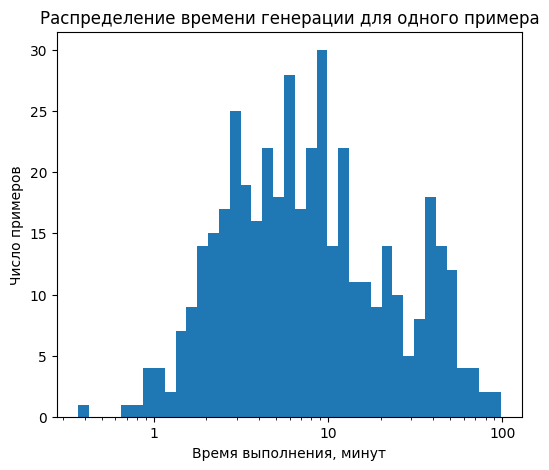

In [118]:
from matplotlib.ticker import ScalarFormatter, LogLocator


fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

bins_log = np.logspace(np.log10(min(glob_mean_times) / 60), np.log10(max(glob_mean_times) / 60), 40)
ax.hist([mt / 60 for mt in glob_mean_times], bins=bins_log)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.set_xlabel("Время выполнения, минут")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение времени генерации для одного примера");

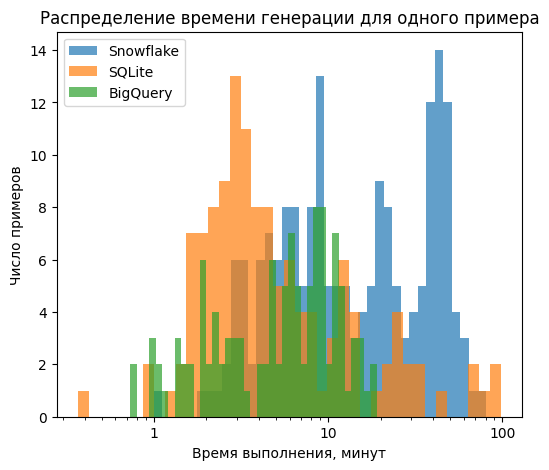

In [119]:
mean_times = {inst: (inst_time[inst] + (exploration_time[inst] if inst in exploration_time else 0))
              for inst in inst_time}
mean_times = {inst: mt for inst, mt in mean_times.items() if mt > 0}


fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

for dial, tags in (("Snowflake", ("sf_bq", "sf0")), ("SQLite", ("local")), ('BigQuery', ('bq', 'ga'))):
    dial_data = [mt / 60 for inst, mt in mean_times.items() if inst.startswith(tags)]
    bins_log = np.logspace(np.log10(min(dial_data)), np.log10(max(dial_data)), 40)
    ax.hist(dial_data, bins=bins_log, alpha=0.7, label=dial)
    # ax.hist(dial_data, bins=40, alpha=0.7, label=dial)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.legend()
ax.set_xlabel("Время выполнения, минут")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение времени генерации для одного примера");

In [140]:
steps = {}
for inst in step_time1:
    for step_name in steps.keys():
        steps[step_name][inst] = []

    for cand in step_time1[inst]:
        if len(cand) < 2:
            continue
        
        for step_name in steps.keys():
            steps[step_name][inst].append([])

        for i in range(1, len(cand)):
            step_name = cand[i][1]
            extime = cand[i][0]
            if (step_name.startswith('[') 
                and not step_name.startswith(("[Error", "[Results",  "[Successfully", "[Try"))
                and not step_name.endswith("output")
            ):
                extime = (extime - cand[i - 1][0]).seconds
                if not step_name.endswith(']'):
                    step_name = step_name.split('] ', 1)[0] + ']'
            
                if not steps.get(step_name):
                    steps[step_name] = {inst: [[]]}
                elif not steps[step_name].get(inst):
                    steps[step_name][inst] = [[]]

                steps[step_name][inst][-1].append(extime)



for inst in step_time2:
    for step_name in steps.keys():
        if not steps[step_name].get(inst):
            steps[step_name][inst] = []

    for cand in step_time2[inst]:
        if len(cand) < 2:
            continue
        
        if not cand[1][1].startswith("[Exploration]"):
            break

        for step_name in steps.keys():
            if steps[step_name].get(inst):
                steps[step_name][inst].append([])

        for i in range(1, len(cand)):
            step_name = cand[i][1]
            extime = cand[i][0]
            if (step_name.startswith('[') 
                and not step_name.startswith(("[Error", "[Successfully", "[Results", "[Try"))
                and not step_name.endswith("output")
            ):
                extime = (extime - cand[i - 1][0]).seconds
                if not step_name.endswith(']'):
                    step_name = step_name.split('] ', 1)[0] + ']'
            
                if not steps.get(step_name):
                    steps[step_name] = {inst: [[]]}
                elif not steps[step_name].get(inst):
                    steps[step_name][inst] = [[]]

                steps[step_name][inst][-1].append(extime)


In [141]:
steps = {step_name: {inst: [sum(cand) for cand in steps[step_name][inst] if cand] 
                     for inst in steps[step_name] if steps[step_name][inst]} 
         for step_name in steps.keys()}

In [142]:
step_means = {step_name: sum(cand for inst in steps[step_name] for cand in steps[step_name][inst] if cand > 0) 
                         / sum(len(steps[step_name][inst]) for inst in steps[step_name] if steps[step_name][inst])
              for step_name in steps}
step_means = sorted(list(step_means.items()), key=lambda x: -x[1])
for step_name, mean_time in step_means:
    print(f"{step_name} ({len(steps[step_name])}):\tв среднем {int(mean_time // 60):0>2}:{int(mean_time % 60):0>2} минут")


[Corrected SQL] (115):	в среднем 06:38 минут
[Self-refine] (430):	в среднем 04:14 минут
[Explore and Correct SQL] (116):	в среднем 02:36 минут
[Exploration] (117):	в среднем 01:51 минут


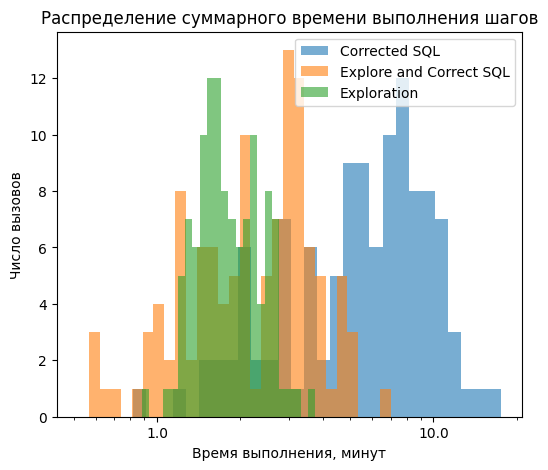

In [143]:
fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)
for step_name, _ in sorted(step_means, key=lambda x: len(steps[x[0]])):
    if step_name == "[Self-refine]":
        continue

    data = [sum(steps[step_name][inst]) / len(steps[step_name][inst]) / 60 
            for inst in steps[step_name] if steps[step_name][inst]]
    bins_log = np.logspace(np.log10(min(data) + 1e-3), np.log10(max(data) + 1e-3), 30)
    ax.hist(data, label=step_name[1:-1], alpha=0.6, bins=bins_log)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((-3, 4))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))

ax.legend()
ax.set_xlabel("Время выполнения, минут")
ax.set_ylabel("Число вызовов")
ax.set_title("Распределение суммарного времени выполнения шагов");

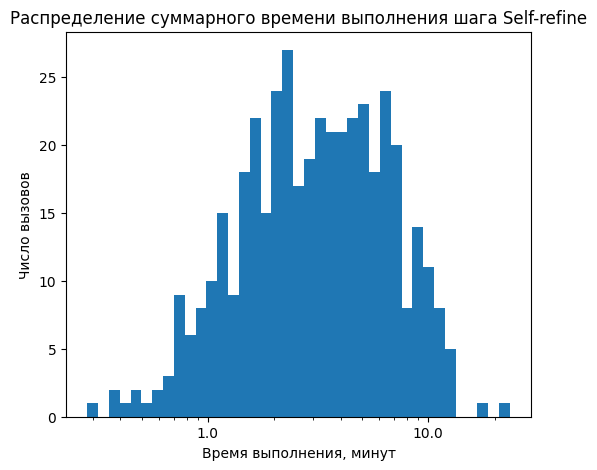

In [144]:
fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

step_name = "[Self-refine]"
data = [sum(steps[step_name][inst]) / len(steps[step_name][inst]) / 60 
        for inst in steps[step_name] if steps[step_name][inst]]
bins_log = np.logspace(np.log10(min(data)), np.log10(max(data)), 40)
ax.hist(data, bins=bins_log)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 4))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))

ax.set_xlabel("Время выполнения, минут")
ax.set_ylabel("Число вызовов")
ax.set_title(f"Распределение суммарного времени выполнения шага {step_name[1:-1]}");

## Стоимость

### Стоимость предобработки

In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("stepfun-ai/Step-3.5-Flash")

def get_tokens_count(text: str, tokenizer):
    return len(tokenizer.encode(text))

In [34]:
import os
import sys
sys.path.insert(0, "..")

from benchmarks.Spider2.methods.ReFoRCE.utils import get_dictionary, get_tb_info, get_external

ask_prompt = """
You are doing table level schema linking. Given a table with schema information and the task, you should think step by step and decide whether this table is related to the task. 
You should answer Y/N only. If the answer is Y, you should add columns that you think is related in python list format.

Please answer only in json code block like:
```json
{{
    "think": "think step by step to decide",
    "answer": "Y or N only",
    "columns": [col_name1, col_name2]
}}
```

Table info: {0}
Task: {1}
{2}
"""

prepr_calls = {}
prepr_folder = rf"..\benchmarks\Spider2\methods\ReFoRCE\examples_{dataset.split('-')[1]}"
dictionaries, task_dict = get_dictionary(prepr_folder, dataset.split('-')[1])
for inst in os.listdir(prepr_folder):
    try:
        with open(os.path.join(prepr_folder, inst, "prompts.txt"), 'r', encoding='utf-8') as f:
            prompt = f.read()
            tbs = get_tb_info(prompt)
            external = get_external(prompt)

            prepr_calls[inst] = {
                'total_tables': [tb.split('\n', 1)[0].rsplit(' ', 1)[1] 
                                 for tb in tbs], 
                'calls': []
            }

        with open(os.path.join(prepr_folder, inst, 'log.log'), 'r', encoding='utf-8') as f:
            prepr_logs = f.read().strip()

    except FileNotFoundError:
        if prepr_calls.get(inst) is not None:
            del prepr_calls[inst]

        continue
    
    state = None
    for line in prepr_logs.splitlines():
        if line == "user:":
            prepr_calls[inst]['calls'].append({'table': None, 'input': "", 'output': ""})
            state = 'input'
            continue
        elif line == "assistant:":
            # Убираем пустые строки у промпта
            prepr_calls[inst]['calls'][-1]['input'] = prepr_calls[inst]['calls'][-1]['input'].strip()
            state = 'output'
            continue
        elif line == "[Schema linking]":
            # Убираем пустые строки у ответа
            prepr_calls[inst]['calls'][-1]['output'] = prepr_calls[inst]['calls'][-1]['output'].strip()

            prepr_calls[inst]['calls'][-1]['input'] = get_tokens_count(prepr_calls[inst]['calls'][-1]['input'], tokenizer)
            prepr_calls[inst]['calls'][-1]['output'] = get_tokens_count(prepr_calls[inst]['calls'][-1]['output'], tokenizer)
            state = None
            continue
        
        if state == 'input':
            prepr_calls[inst]['calls'][-1]['input'] += line + '\n'
            if line.startswith("Table info: Table full name: "):
                prepr_calls[inst]['calls'][-1]['table'] = line.rsplit(' ', 1)[1]

        elif state == 'output':
            prepr_calls[inst]['calls'][-1]['output'] += line + '\n'
        
    skipped_tables = set(prepr_calls[inst]['total_tables']) - {call['table'] for call in prepr_calls[inst]['calls']}
    if not skipped_tables:
        continue

    for i in range(len(prepr_calls[inst]['total_tables'])):
        tb_name = prepr_calls[inst]['total_tables'][i]
        if tb_name not in skipped_tables:
            continue

        prepr_calls[inst]['calls'].append({
            'table': tb_name, 
            'input': get_tokens_count(ask_prompt.format(tbs[i], task_dict[inst], external), tokenizer), 
            'output': None
        })


In [35]:
group_pre_calls = {group: {'input': [], 'output': []} for group in ['bq', 'ga', 'local', 'sf_bq', 'sf0']}
for inst in prepr_time:
    for group in group_pre_calls:
        if inst.startswith(group):
            group_pre_calls[group]['input'].append([call['input'] for call in prepr_calls[inst]['calls']])
            group_pre_calls[group]['output'].append([call['output'] for call in prepr_calls[inst]['calls'] 
                                                     if call['output'] is not None])
            break

print({group: sum(len(group_pre_calls[group]['input'][i]) for i in range(len(group_pre_calls[group]['input']))) 
       for group in group_pre_calls})

{'bq': 5589, 'ga': 25, 'local': 0, 'sf_bq': 4058, 'sf0': 521}


In [36]:
mean_pre_calls = {
    group: {
        'input': sum(sum(calls) for calls in group_pre_calls[group]['input'])
                 / sum(len(calls) for calls in group_pre_calls[group]['input']),

        'output': sum(sum(calls) for calls in group_pre_calls[group]['output']) 
                  / sum(len(calls) for calls in group_pre_calls[group]['output'])
    }
    for group in group_pre_calls if group_pre_calls[group]['input']}
mean_pre_calls

{'bq': {'input': 2648.5382000357845, 'output': 157.72906403940885},
 'ga': {'input': 5279.92, 'output': 169.4090909090909},
 'sf_bq': {'input': 2611.462789551503, 'output': 166.30539241857983},
 'sf0': {'input': 2091.8790786948175, 'output': 182.68682505399568}}

In [37]:
# Вместо неизвестного числа выходных токенов добавляем среднее по группе
for inst in prepr_calls:
    group = None
    for gr in group_pre_calls:
        if inst.startswith(gr):
            group = gr
            break
    
    for i in range(len(prepr_calls[inst]['calls'])):
        if prepr_calls[inst]['calls'][i]['output'] is None:
            prepr_calls[inst]['calls'][i]['output'] = mean_pre_calls[group]['output']
            

In [38]:
# число вызовов
new_group_pre_calls = {group: {'input': [], 'output': []} for group in ['bq', 'ga', 'local', 'sf_bq', 'sf0']}
for inst in prepr_time:
    for group in new_group_pre_calls:
        if inst.startswith(group):
            new_group_pre_calls[group]['input'].append([call['input'] for call in prepr_calls[inst]['calls']])
            new_group_pre_calls[group]['output'].append([call['output'] for call in prepr_calls[inst]['calls']])
            break

print({group: sum(len(calls) for calls in new_group_pre_calls[group]['input'])
       for group in new_group_pre_calls})

{'bq': 5589, 'ga': 25, 'local': 0, 'sf_bq': 4058, 'sf0': 521}


In [56]:
print("Предобработка\n")
print(f"Число входных токенов {sum(sum(sum(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls):,d}")
print(f"Число выходных токенов: {int(sum(sum(sum(calls) for calls in new_group_pre_calls[group]['output']) for group in new_group_pre_calls)):,d}")
print(f"Число вызовов: {sum(sum(len(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls):,d}")

print("\nВ среднем на пример")
print(f"Число входных токенов {round(sum(sum(sum(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls) / len(prepr_calls)):,d}")
print(f"Число выходных токенов: {round(sum(sum(sum(calls) for calls in new_group_pre_calls[group]['output']) for group in new_group_pre_calls) / len(prepr_calls)):,d}")
print(f"Число вызовов: {sum(sum(len(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls) / len(prepr_calls):.0f}")

Предобработка

Число входных токенов 26,621,863
Число выходных токенов: 1,655,830
Число вызовов: 10,193

В среднем на пример
Число входных токенов 64,616
Число выходных токенов: 4,019
Число вызовов: 25


### Стоимость генерации

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("stepfun-ai/Step-3.5-Flash")
def get_tokens_count(text: str, tokenizer):
    return len(tokenizer.encode(text))

In [57]:
import json
from datetime import datetime

logs1 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs1.json", 'r', encoding='utf-8'))
logs2 = json.load(open(f"..\\results\\logs\\{dataset}\\reforce_logs2.json", 'r', encoding='utf-8'))

In [58]:
step_tokens1, step_tokens2 = {}, {}
calls1, calls2 = {}, {}
for (step_tokens, calls, logs) in ((step_tokens1, calls1, logs1), (step_tokens2, calls2, logs2)):
    for inst in logs:
        step_tokens[inst] = []
        calls[inst] = []
        for cand in logs[inst]:
            if len(logs[inst][cand]) > 0:
                step_tokens[inst].append([])

            calls[inst].append(0)
            for line in logs[inst][cand]:
                if line[1].endswith('input'):
                    step_tokens[inst][-1].append({
                        'step': line[1].rsplit(' ', 1)[0], 
                        'input': get_tokens_count(line[2], tokenizer)
                    })
                    if len(step_tokens[inst][-1]) > 1:
                        add_context = step_tokens[inst][-1][-2]['input']
                        if len(step_tokens[inst][-1]) > 10:
                            add_context -= step_tokens[inst][-1][-10]['input'] 
                            add_context += (
                                step_tokens[inst][-1][-11]['input'] 
                                if len(step_tokens[inst][-1]) > 11
                                else 0
                            )

                        step_tokens[inst][-1][-1]['input'] += add_context
                    
                elif line[1].endswith('output'):
                    step_tokens[inst][-1][-1]['output'] = get_tokens_count(line[2], tokenizer)
                    calls[inst][-1] += 1


In [59]:
all_tokens1 = {
    'input': sum(sum(line['input'] for line in cand) for inst in step_tokens1 for cand in step_tokens1[inst]),
    'output': sum(sum(line['output'] for line in cand) for inst in step_tokens1 for cand in step_tokens1[inst])
}
all_tokens2 = {
    'input': sum(sum(line['input'] for line in cand) for inst in step_tokens2 for cand in step_tokens2[inst] 
                 if cand and cand[0]['step'].startswith("[Exploration]")),
    'output': sum(sum(line['output'] for line in cand) for inst in step_tokens2 for cand in step_tokens2[inst]
                  if cand and cand[0]['step'].startswith("[Exploration]"))
}
print(f"До column exploration\n\tВсего входных токенов {all_tokens1['input']:,d}\n\tвыходных: {all_tokens1['output']:,d}")
print(f"Включая column exploration\n\tВсего входных токенов {all_tokens1['input'] + all_tokens2['input']:,d}\n\tвыходных: {all_tokens1['output'] + all_tokens2['output']:,d}")

До column exploration
	Всего входных токенов 120,317,924
	выходных: 3,567,797
Включая column exploration
	Всего входных токенов 234,183,347
	выходных: 6,800,219


In [60]:
inst_tokens = {
    'input': {inst: sum(line['input'] for cand in step_tokens1[inst] for line in cand) for inst in step_tokens1},
    'output': {inst: sum(line['output'] for cand in step_tokens1[inst] for line in cand) for inst in step_tokens1}
}
inst_tokens_ce = {
    'input': {inst: (inst_tokens['input'][inst] if inst in inst_tokens['input'] else 0) 
                     + (sum(line['input'] for cand in step_tokens2[inst]
                           if cand and cand[0]['step'] == "[Exploration]" 
                           for line in cand) 
                       if inst in step_tokens2 and step_tokens2[inst] else 0)
              for inst in set(step_tokens1.keys()).union(set(step_tokens2.keys()))
    },
    'output': {inst: (inst_tokens['output'][inst] if inst in inst_tokens['output'] else 0) 
                     + (sum(line['output'] for cand in step_tokens2[inst]
                           if cand and cand[0]['step'] == "[Exploration]" 
                           for line in cand) 
                       if inst in step_tokens2 and step_tokens2[inst] else 0)
               for inst in set(step_tokens1.keys()).union(set(step_tokens2.keys()))
    }
}

inst_tokens['input'] = {inst: mt for inst, mt in inst_tokens['input'].items() if mt > 0}
inst_tokens['output'] = {inst: mt for inst, mt in inst_tokens['output'].items() if mt > 0}
inst_tokens_ce['input'] = {inst: mt for inst, mt in inst_tokens_ce['input'].items() if mt > 0}
inst_tokens_ce['output'] = {inst: mt for inst, mt in inst_tokens_ce['output'].items() if mt > 0}

inst_tokens['input'] = dict(sorted(list(inst_tokens['input'].items()), key=lambda x: x[1]))
inst_tokens['output'] = dict(sorted(list(inst_tokens['output'].items()), key=lambda x: x[1]))
inst_tokens_ce['input'] = dict(sorted(list(inst_tokens_ce['input'].items()), key=lambda x: x[1]))
inst_tokens_ce['output'] = dict(sorted(list(inst_tokens_ce['output'].items()), key=lambda x: x[1]))

In [61]:
print(f"Среднее число входных токенов на пример {int(sum(inst_tokens_ce['input'].values()) / len(inst_tokens_ce['input'])):,d}")
print(f"Среднее число выходных токенов на пример {int(sum(inst_tokens_ce['output'].values()) / len(inst_tokens_ce['output'])):,d}")
print(f"Медиана числа входных токенов на пример {list(inst_tokens_ce['input'].values())[len(inst_tokens_ce['input']) // 2]:,d}")
print(f"Медиана числа выходных токенов на пример {list(inst_tokens_ce['output'].values())[len(inst_tokens_ce['output']) // 2]:,d}")

Среднее число входных токенов на пример 527,439
Среднее число выходных токенов на пример 15,315
Медиана числа входных токенов на пример 101,321
Медиана числа выходных токенов на пример 5,782


In [70]:
print("С предобработкой\n")
print(
    "До column exploration\n\tВсего входных токенов", 
    f"{all_tokens1['input'] + sum(sum(sum(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls):,d}\n\tвыходных:", 
    f"{all_tokens1['output'] + int(sum(sum(sum(calls) for calls in new_group_pre_calls[group]['output']) for group in new_group_pre_calls)):,d}"
)
print(
    "Включая column exploration\n\tВсего входных токенов", 
    f"{all_tokens1['input'] + all_tokens2['input'] + sum(sum(sum(calls) for calls in new_group_pre_calls[group]['input']) for group in new_group_pre_calls):,d}\n\tвыходных:", 
    f"{all_tokens1['output'] + all_tokens2['output'] + int(sum(sum(sum(calls) for calls in new_group_pre_calls[group]['output']) for group in new_group_pre_calls)):,d}"
)

С предобработкой

До column exploration
	Всего входных токенов 146,939,787
	выходных: 5,223,627
Включая column exploration
	Всего входных токенов 260,805,210
	выходных: 8,456,049


In [75]:
from copy import deepcopy

inst_pre_tokens = deepcopy(inst_tokens)
inst_pre_tokens_ce = deepcopy(inst_tokens_ce)
for inst in prepr_calls:
    if inst_pre_tokens['input'].get(inst):
        inst_pre_tokens['input'][inst] += sum(call['input'] for call in prepr_calls[inst]['calls'])
        inst_pre_tokens['output'][inst] += round(sum(call['output'] for call in prepr_calls[inst]['calls']))
    
    if inst_pre_tokens_ce['input'].get(inst):
        inst_pre_tokens_ce['input'][inst] += sum(call['input'] for call in prepr_calls[inst]['calls'])
        inst_pre_tokens_ce['output'][inst] += round(sum(call['output'] for call in prepr_calls[inst]['calls']))


In [77]:
print("С предобработкой\n")
print(f"Среднее число входных токенов на пример {int(sum(inst_pre_tokens_ce['input'].values()) / len(inst_pre_tokens_ce['input'])):,d}")
print(f"Среднее число выходных токенов на пример {int(sum(inst_pre_tokens_ce['output'].values()) / len(inst_pre_tokens_ce['output'])):,d}")
print(f"Медиана числа входных токенов на пример {list(inst_pre_tokens_ce['input'].values())[len(inst_pre_tokens_ce['input']) // 2]:,d}")
print(f"Медиана числа выходных токенов на пример {list(inst_pre_tokens_ce['output'].values())[len(inst_pre_tokens_ce['output']) // 2]:,d}")

С предобработкой

Среднее число входных токенов на пример 556,477
Среднее число выходных токенов на пример 17,369
Медиана числа входных токенов на пример 112,591
Медиана числа выходных токенов на пример 8,925


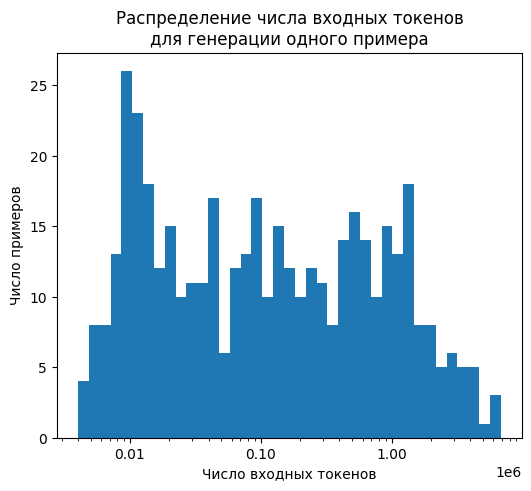

In [190]:
from matplotlib.ticker import ScalarFormatter, LogLocator


fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

data = list(inst_tokens_ce['input'].values())
bins_log = np.logspace(np.log10(min(data)), np.log10(max(data)), 40)
ax.hist(data, bins=bins_log)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.set_xlabel("Число входных токенов")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение числа входных токенов\nдля генерации одного примера");

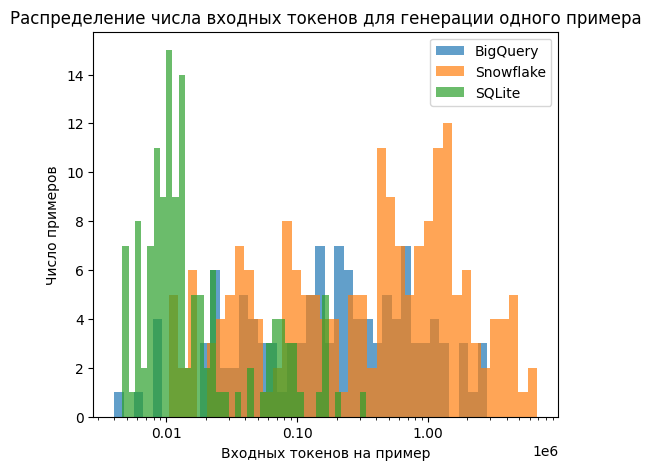

In [191]:
fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

for dial, tags in (('BigQuery', ('bq', 'ga')), ("Snowflake", ("sf_bq", "sf0")), ("SQLite", ("local"))):
    dial_data = [mt for inst, mt in inst_tokens_ce['input'].items() if inst.startswith(tags)]
    bins_log = np.logspace(np.log10(min(dial_data)), np.log10(max(dial_data)), 40)
    ax.hist(dial_data, bins=bins_log, alpha=0.7, label=dial)
    # ax.hist(dial_data, bins=40, alpha=0.7, label=dial)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.legend()
ax.set_xlabel("Входных токенов на пример")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение числа входных токенов для генерации одного примера");

### Число вызовов

In [79]:
import time
from copy import deepcopy

calls = deepcopy(calls2)
for inst in calls:
    if step_tokens2[inst] and step_tokens2[inst][0] and step_tokens2[inst][0][0]['step'] == "[Exploration]":
        calls[inst] = [orig + expl for orig, expl in zip(calls1[inst], calls[inst])]


In [80]:
print("До column exploration")
print(f"Всего вызовов LLM: {sum(sum(cand) for cand in calls1.values())}")
print(f"Среднее число вызовов LLM на пример: {sum(sum(cand) for cand in calls1.values()) / sum(1 for cand in calls1.values() if sum(cand) > 0):.2f}")

print("\nОбщее число вызовов")
print(f"Всего вызовов LLM: {sum(sum(cand) for cand in calls.values())}")
print(f"Среднее число вызовов LLM на пример: {sum(sum(cand) for cand in calls.values()) / sum(1 for cand in calls.values() if sum(cand) > 0):.2f}")

До column exploration
Всего вызовов LLM: 7761
Среднее число вызовов LLM на пример: 17.48

Общее число вызовов
Всего вызовов LLM: 13384
Среднее число вызовов LLM на пример: 30.63


In [85]:
total_pre_calls = {inst: sum(cand) + (len(prepr_calls[inst]['calls']) if prepr_calls.get(inst) else 0) 
                   for inst, cand in calls1.items()}
total_pre_calls_ce = {inst: sum(cand) + (len(prepr_calls[inst]['calls']) if prepr_calls.get(inst) else 0) 
                      for inst, cand in calls.items()}

In [86]:
print("С учётом предобработки\n\nДо column exploration")
print(f"Всего вызовов LLM: {sum(total_pre_calls.values())}")
print(f"Среднее число вызовов LLM на пример: {sum(total_pre_calls.values()) / sum(1 for c in total_pre_calls.values() if c > 0):.2f}")

print("\nОбщее число вызовов")
print(f"Всего вызовов LLM: {sum(total_pre_calls_ce.values())}")
print(f"Среднее число вызовов LLM на пример: {sum(total_pre_calls_ce.values()) / sum(1 for c in total_pre_calls_ce.values() if c > 0):.2f}")

С учётом предобработки

До column exploration
Всего вызовов LLM: 15227
Среднее число вызовов LLM на пример: 32.54

Общее число вызовов
Всего вызовов LLM: 23577
Среднее число вызовов LLM на пример: 43.34


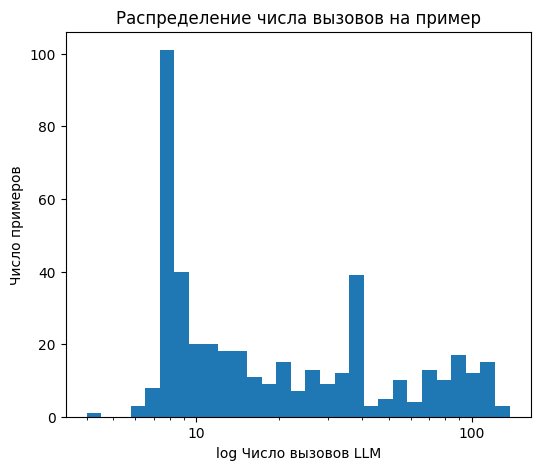

In [85]:
from matplotlib.ticker import ScalarFormatter, LogLocator

fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

data = [sum(cand) for cand in calls.values() if sum(cand) > 0]
bins_log = np.logspace(np.log10(min(data)), np.log10(max(data)), 30)
ax.hist(data, bins=bins_log)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.set_xlabel("log Число вызовов LLM")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение числа вызовов на пример");

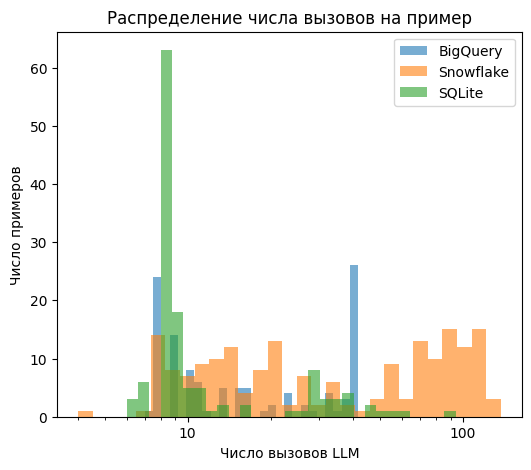

In [86]:
fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(5)

for dial, tags in (('BigQuery', ('bq', 'ga')), ("Snowflake", ("sf_bq", "sf0")), ("SQLite", ("local"))):
    dial_data = [sum(cand) for inst, cand in calls.items() if inst.startswith(tags) and sum(cand) > 0]
    bins_log = np.logspace(np.log10(min(dial_data)), np.log10(max(dial_data)), 30)
    ax.hist(dial_data, alpha=0.6, bins=bins_log, label=dial)

ax.set_xscale('log')
formatter1 = ScalarFormatter()
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 5))

ax.xaxis.set_major_formatter(formatter1)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

ax.legend()
ax.set_xlabel("Число вызовов LLM")
ax.set_ylabel("Число примеров")
ax.set_title("Распределение числа вызовов на пример");